In [246]:
from urllib.request import urlretrieve
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import zipfile
import joblib
import bs4
import os
import re

In [2]:
SRC_LIST_PATH = os.path.join("data", "docs", "databank-list.txt")

with open(SRC_LIST_PATH, 'r') as f:
    databank_list = [src.strip('\n') for src in f.readlines()]

databank_list

['Agricultural land (% of land area)',
 'Food production index (2014-2016 = 100)',
 'Forest area (% of land area)',
 'Rural population (% of total population)',
 'Net migration',
 'Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)',
 'Pregnant women receiving prenatal care (%)',
 'Prevalence of HIV, total (% of population ages 15-49)',
 'Primary completion rate, total (% of relevant age group)',
 'School enrollment, primary and secondary (gross), gender parity index (GPI)',
 'Access to electricity (% of population)',
 'Population growth (annual %)',
 'Population in urban agglomerations of more than 1 million (% of total population)',
 'Population living in areas where elevation is below 5 meters (% of total population)',
 'Terrestrial and marine protected areas (% of total territorial area)',
 'Urban population (% of total population)',
 'Central government debt, total (% of GDP)',
 'Expense (% of GDP)',
 'GDP growth (annual %)',
 'GDP per capita growth (annual %)',
 

In [3]:
DATABANK_URL = "https://data.worldbank.org/indicator"
DATABANK_INDICATORS_PATH = os.path.join("data", "html", "databank-indicators.html")

if not os.path.exists(DATABANK_INDICATORS_PATH):
    urlretrieve(DATABANK_URL, DATABANK_INDICATORS_PATH)

In [4]:
with open(DATABANK_INDICATORS_PATH, 'r', encoding='utf-8') as f:
    html_text = f.read()
    soup = bs4.BeautifulSoup(html_text, 'html.parser')
    indicator_links = soup.find_all('a', href=re.compile("/indicator/"))

In [5]:
API_DOWNLOAD_URL = "https://api.worldbank.org/v2/en/indicator/"
download_links = []
for indicator_name in databank_list:
    name = indicator_name.replace(" ", "").lower()
    for link in indicator_links:
        if link.text.replace(" ", "").lower() == name:
            code = link.get("href").split("/")[2]
            download_url = f"{API_DOWNLOAD_URL}{code}?downloadformat=csv"
            download_links.append((indicator_name, code, download_url))
download_links

[('Agricultural land (% of land area)',
  'AG.LND.AGRI.ZS',
  'https://api.worldbank.org/v2/en/indicator/AG.LND.AGRI.ZS?downloadformat=csv'),
 ('Agricultural land (% of land area)',
  'AG.LND.AGRI.ZS',
  'https://api.worldbank.org/v2/en/indicator/AG.LND.AGRI.ZS?downloadformat=csv'),
 ('Agricultural land (% of land area)',
  'AG.LND.AGRI.ZS',
  'https://api.worldbank.org/v2/en/indicator/AG.LND.AGRI.ZS?downloadformat=csv'),
 ('Food production index (2014-2016 = 100)',
  'AG.PRD.FOOD.XD',
  'https://api.worldbank.org/v2/en/indicator/AG.PRD.FOOD.XD?downloadformat=csv'),
 ('Forest area (% of land area)',
  'AG.LND.FRST.ZS',
  'https://api.worldbank.org/v2/en/indicator/AG.LND.FRST.ZS?downloadformat=csv'),
 ('Forest area (% of land area)',
  'AG.LND.FRST.ZS',
  'https://api.worldbank.org/v2/en/indicator/AG.LND.FRST.ZS?downloadformat=csv'),
 ('Forest area (% of land area)',
  'AG.LND.FRST.ZS',
  'https://api.worldbank.org/v2/en/indicator/AG.LND.FRST.ZS?downloadformat=csv'),
 ('Rural population

In [6]:
for name, code, url in download_links:
    path = os.path.join("data", "zip", f"{name}.zip")
    if not os.path.exists(path):
        urlretrieve(url, path)

In [7]:
ZIP_PATH = os.path.join("data", "zip")
CSV_PATH = os.path.join("data", "csv")

In [8]:
for file in os.listdir(ZIP_PATH):
    file_dir = os.path.join(CSV_PATH, file.replace(".zip", ""))
    if not os.path.exists(file_dir):
        os.mkdir(file_dir)
        zipfile.ZipFile(os.path.join(ZIP_PATH, file), 'r').extractall(file_dir)

In [9]:
# Get happiness data
HAPPINESS_URL = "https://files.worldhappiness.report/WHR26_Data_Figure_2.1.xlsx"

# Automated retrieval is forbidden (403), so manual retrieval was needed.
# File is stored, manually, in defined location at `data/xlsx/happiness_report.xlsx`
# urlretrieve(HAPPINESS_URL, os.path.join("data", "xlsx", "happiness_report.xlsx"))

# Data preliminary exploration

## Happiness data

In [10]:
happiness = pd.read_excel(os.path.join("data", "xlsx", "happiness_report.xlsx"))
happiness.head()

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


In [11]:
happiness.info()

<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   str    
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by: Generosit

We are interested in the year, country name, and life evaluation average.

In [12]:
happiness["Life evaluation (3-year average)"].describe()

count    2116.000000
mean        5.465655
std         1.123870
min         1.364000
25%         4.604750
50%         5.480000
75%         6.321250
max         7.856000
Name: Life evaluation (3-year average), dtype: float64

In [13]:
happiness_df = happiness.loc[:, ["Year", "Country name", "Life evaluation (3-year average)"]]
MAX_YEAR, MIN_YEAR = happiness_df["Year"].max(), happiness_df["Year"].min()
COUNTRIES_LIST = happiness_df["Country name"].unique()

MAX_YEAR, MIN_YEAR, COUNTRIES_LIST

(np.int64(2025),
 np.int64(2011),
 <StringArray>
 [          'Finland',           'Iceland',           'Denmark',
         'Costa Rica',            'Sweden',            'Norway',
        'Netherlands',            'Israel',        'Luxembourg',
        'Switzerland',
  ...
             'Bhutan',             'Syria',             'Sudan',
             'Angola',       'Puerto Rico',          'Suriname',
  'Somaliland Region',          'Djibouti',            'Guyana',
               'Cuba']
 Length: 168, dtype: str)

## Bank data

In [14]:
indicator_names = os.listdir(CSV_PATH)
indicator_files = dict()
for indicator in indicator_names:
    dir_path = os.path.join(CSV_PATH, indicator)
    if os.path.isdir(dir_path):
        files = os.listdir(dir_path)
        for f in files:
            if not f.startswith("Metadata"):
                indicator_files[indicator] = os.path.join(CSV_PATH, indicator, f)
indicator_files

{'Access to electricity (% of population)': 'data\\csv\\Access to electricity (% of population)\\API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_3606.csv',
 'Agricultural land (% of land area)': 'data\\csv\\Agricultural land (% of land area)\\API_AG.LND.AGRI.ZS_DS2_en_csv_v2_7781.csv',
 'Alternative and nuclear energy (% of total energy use)': 'data\\csv\\Alternative and nuclear energy (% of total energy use)\\API_EG.USE.COMM.CL.ZS_DS2_en_csv_v2_7080.csv',
 'Central government debt, total (% of GDP)': 'data\\csv\\Central government debt, total (% of GDP)\\API_GC.DOD.TOTL.GD.ZS_DS2_en_csv_v2_5449.csv',
 'Expense (% of GDP)': 'data\\csv\\Expense (% of GDP)\\API_GC.XPN.TOTL.GD.ZS_DS2_en_csv_v2_2867.csv',
 'Food production index (2014-2016 = 100)': 'data\\csv\\Food production index (2014-2016 = 100)\\API_AG.PRD.FOOD.XD_DS2_en_csv_v2_15376.csv',
 'Forest area (% of land area)': 'data\\csv\\Forest area (% of land area)\\API_AG.LND.FRST.ZS_DS2_en_csv_v2_4195.csv',
 'Fossil fuel energy consumption (% of tota

**Note:** Every csv file starts at row 2!

### Access to electricity

In [15]:
electricity = pd.read_csv(indicator_files["Access to electricity (% of population)"], header=2)
electricity.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,100.000000,100.000000,100.000000,100.000000,100.000000,99.900000,100.000000,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,40.223744,43.035073,44.390861,46.282371,48.127211,48.801258,50.667516,NaN,NaN,NaN
2,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,97.700000,93.400000,97.700000,97.700000,97.700000,85.300000,85.300000,NaN,NaN,NaN
3,Africa Western and Central,AFW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,48.902228,51.338199,51.289374,51.851866,54.366012,55.683570,57.064737,NaN,NaN,NaN
4,Angola,AGO,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,42.900000,45.300000,45.600000,47.000000,48.200000,48.500000,51.100000,NaN,NaN,NaN


In [16]:
electricity.describe(), electricity.info()

<class 'pandas.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    265 non-null    str    
 1   Country Code    265 non-null    str    
 2   Indicator Name  265 non-null    str    
 3   Indicator Code  265 non-null    str    
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      float64
 18  1

(       1960  1961  1962  1963  1964  1965  1966  1967  1968  1969  ...  \
 count   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
 mean    NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
 std     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
 min     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
 25%     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
 50%     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
 75%     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
 max     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
 
              2017        2018        2019        2020        2021        2022  \
 count  262.000000  262.000000  262.000000  262.000000  262.000000  262.000000   
 mean    84.677662   85.315478   85.874072   86.408904   86.969251   87.263447   
 std     24.907559   24.049449   23.793819   23.387846   22.846938   22.45256

# Data preparation

In [17]:
# Melting the bank data df
id_vars = ["Country Name", "Indicator Name"]
year_cols = [col for col in electricity.columns if col.isdigit()]
electricity_long = pd.melt(electricity,
        id_vars=id_vars,
        value_vars=year_cols,
        var_name="Year",
        value_name="Value")

# For compatibility, transform year strings into integers:
electricity_long["Year"] = electricity_long["Year"].astype("int")

# Now, Indicator Name must be removed and the Value column should be renamed:
indicator_name = electricity_long["Indicator Name"][0]
electricity_long.rename(columns={"Value": indicator_name}, inplace=True)
electricity_long.drop(columns=["Indicator Name"], inplace=True)

# Also, the country column should be renamed for compatibility:
electricity_long.rename(columns={"Country Name":"Country name"}, inplace=True)

# Check the results
electricity_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 17490 entries, 0 to 17489
Data columns (total 3 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Country name                             17490 non-null  str    
 1   Year                                     17490 non-null  int64  
 2   Access to electricity (% of population)  7835 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 410.1 KB


In [18]:
electricity_long.sample(5)

,Country name,Year,Access to electricity (% of population)
7911,Syrian Arab Republic,1989,NaN
14950,Ireland,2016,100.0
15595,Seychelles,2018,100.0
59,Dominican Republic,1960,NaN
12698,Turkiye,2007,99.7


Note that some countries have different naming conventions, such as Yemen:
In "Happiness", it's called "Yemen", whereas in Bank data, it can be found as "Yemen, Rep.".

A naive approach will be taken, where we only replace the string ", Rep." and assume the rest of the countries are correctly formatted as the Happiness data's standard.

In [19]:
electricity_long.tail(5)

,Country name,Year,Access to electricity (% of population)
17485,Kosovo,2025,NaN
17486,"Yemen, Rep.",2025,NaN
17487,South Africa,2025,NaN
17488,Zambia,2025,NaN
17489,Zimbabwe,2025,NaN


In [20]:
electricity_long["Country name"] = electricity_long.loc[:, "Country name"].str.replace(", Rep.", "")
electricity_long.tail(5)

,Country name,Year,Access to electricity (% of population)
17485,Kosovo,2025,NaN
17486,Yemen,2025,NaN
17487,South Africa,2025,NaN
17488,Zambia,2025,NaN
17489,Zimbabwe,2025,NaN


In [21]:
# Reindex
pd.merge(happiness, electricity_long, on=["Country name", "Year"])

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,Access to electricity (% of population)
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582,NaN
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373,NaN
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310,NaN
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236,NaN
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1891,2011,152,Burundi,3.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.2
1892,2011,153,Sierra Leone,3.586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.2
1893,2011,154,Central African Republic,3.568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.4
1894,2011,155,Benin,3.493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.9


## Data reunification
Now that our simple pipeline worked, we can iterate over every dataset to merge it with our happiness df.

In [22]:
def unify(indicator_name:str, final_df: pd.DataFrame, indicator_df: pd.DataFrame) -> pd.DataFrame:
    # Melting the bank data df
    id_vars = ["Country Name", "Indicator Name"]
    year_cols = [col for col in indicator_df.columns if col.isdigit()]
    df_melted = pd.melt(indicator_df,
            id_vars=id_vars,
            value_vars=year_cols,
            var_name="Year",
            value_name="Value")

    # For compatibility, transform year strings into integers:
    df_melted["Year"] = df_melted["Year"].astype("int")

    # Now, Indicator Name must be removed and the Value column should be renamed:
    df_melted.rename(columns={"Value": indicator_name}, inplace=True)
    df_melted.drop(columns=["Indicator Name"], inplace=True)

    # Also, the country column should be renamed for compatibility:
    df_melted.rename(columns={"Country Name": "Country name"}, inplace=True)

    # Naive correction of country names
    df_melted["Country name"] = df_melted.loc[:, "Country name"].str.replace(", Rep.", "")


    return pd.merge(final_df, df_melted, on=["Country name", "Year"])

In [23]:
final_df = happiness
for indicator_name, filepath in indicator_files.items():
    # Remember that files start at the second row!
    indicator_df = pd.read_csv(filepath, header=2)
    # Iteratively unify datasets
    final_df = unify(indicator_name, final_df, indicator_df)

In [24]:
final_df.head()

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,...,Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population),Pregnant women receiving prenatal care (%),"Prevalence of HIV, total (% of population ages 15-49)","Primary completion rate, total (% of relevant age group)",Renewable electricity output (% of total electricity output),Rural population (% of total population),"School enrollment, primary and secondary (gross), gender parity index (GPI)",Terrestrial and marine protected areas (% of total territorial area),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,...,NaN,NaN,NaN,NaN,NaN,25.475216,NaN,13.5,9.461,74.524784
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,...,NaN,NaN,NaN,NaN,NaN,5.782068,NaN,2.9,3.625,94.217932
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,...,NaN,NaN,NaN,NaN,NaN,11.154156,NaN,23.8,5.529,88.845844
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,...,0.8,NaN,NaN,NaN,NaN,20.273186,NaN,28.2,6.843,79.726814
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,...,NaN,NaN,NaN,NaN,NaN,10.922132,NaN,15.9,8.694,89.077868


In [25]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1896 entries, 0 to 1895
Data columns (total 43 columns):
 #   Column                                                                                        Non-Null Count  Dtype  
---  ------                                                                                        --------------  -----  
 0   Year                                                                                          1896 non-null   int64  
 1   Rank                                                                                          1896 non-null   int64  
 2   Country name                                                                                  1896 non-null   str    
 3   Life evaluation (3-year average)                                                              1896 non-null   float64
 4   Lower whisker                                                                                 919 non-null    float64
 5   Upper whisker                         

In [26]:
def save_csv(filename: str, df: pd.DataFrame):
    path = os.path.join("data", "csv", filename + ".csv")
    if not os.path.exists(path):
        df.to_csv(path)
    else:
        print("File already exists. Skiping!")

save_csv("joint_data_v1", final_df)

File already exists. Skiping!


## Data cleaning
As seen above, some features do not have enough data to be useful.

For example, "Pregnant women receiving prenatal care (%)" is full of null values. This feature hardly could mean that most contries do not receive prenatal care; i.e.: most countries not supporting at all parenting, but also we do not have enough data to replace nullish values for a statistical measurement like the mean, so we better drop this feature.

Another feature with not enough data is the "Central government debt, total (% of GDP)",  column, so it'll be dropped as well.

One important note here is that the world bank datasets often use grouped countries along with individual ones; e.g.: "Sub-Saharan Africa (IDA & IBRD countries)". With this in mind, we can use the list of countries collected at the beginning after loading the happiness dataset to filter the data. Also, the usable years are defined by the range available in the Happiness report, also stored in variables at the start of the exploration.

Another important point is that many years do not have enough data for every feature, but we'll check that after dropping the features mentioned above.

Finally, we'll drop columns not usable such as the "Rank", "Lower whisker", and "Upper whisker" columns, whose information is already provided (at least partially) by the "Life evaluation (3-year average)" column.

In [27]:
# Drop unusable columns 
df = final_df.drop(columns=["Rank", "Lower whisker", "Upper whisker", "Pregnant women receiving prenatal care (%)", "Central government debt, total (% of GDP)"])

In [28]:
# Filter by recognized country names (using Happiness report's countries as standard)
country_filtered = df[df["Country name"].isin(COUNTRIES_LIST)]

In [29]:
# Filter usable years
year_filtered = country_filtered.loc[(country_filtered["Year"] <= MAX_YEAR) & (country_filtered["Year"] >= MIN_YEAR)]
year_filtered

,Year,Country name,Life evaluation (3-year average),Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,...,Population living in slums (% of urban population),Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population),"Prevalence of HIV, total (% of population ages 15-49)","Primary completion rate, total (% of relevant age group)",Renewable electricity output (% of total electricity output),Rural population (% of total population),"School enrollment, primary and secondary (gross), gender parity index (GPI)",Terrestrial and marine protected areas (% of total territorial area),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
0,2025,Finland,7.764,1.915,1.638,0.939,1.105,0.093,0.491,1.582,...,NaN,NaN,NaN,NaN,NaN,25.475216,NaN,13.5,9.461,74.524784
1,2025,Iceland,7.540,1.971,1.720,0.996,1.105,0.187,0.187,1.373,...,NaN,NaN,NaN,NaN,NaN,5.782068,NaN,2.9,3.625,94.217932
2,2025,Denmark,7.539,1.986,1.633,0.930,1.081,0.125,0.474,1.310,...,NaN,NaN,NaN,NaN,NaN,11.154156,NaN,23.8,5.529,88.845844
3,2025,Costa Rica,7.439,1.697,1.483,0.739,1.101,0.059,0.122,2.236,...,NaN,0.8,NaN,NaN,NaN,20.273186,NaN,28.2,6.843,79.726814
4,2025,Sweden,7.255,1.950,1.570,1.027,1.070,0.149,0.447,1.041,...,NaN,NaN,NaN,NaN,NaN,10.922132,NaN,15.9,8.694,89.077868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1891,2011,Burundi,3.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.6,57.807852,91.756593,88.438335,0.95414,NaN,1.602,11.561665
1892,2011,Sierra Leone,3.586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,53.7,1.6,67.883131,87.097141,60.952785,0.90074,NaN,4.388,39.047215
1893,2011,Central African Republic,3.568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,4.6,37.128670,99.824179,61.196933,0.70590,NaN,5.638,38.803067
1894,2011,Benin,3.493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,68.4,1.1,67.323730,0.000000,56.538386,0.80969,NaN,2.647,43.461614


In [30]:
year_filtered.iloc[:, 3:].describe()

,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,Access to electricity (% of population),Agricultural land (% of land area),Alternative and nuclear energy (% of total energy use),...,Population living in slums (% of urban population),Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population),"Prevalence of HIV, total (% of population ages 15-49)","Primary completion rate, total (% of relevant age group)",Renewable electricity output (% of total electricity output),Rural population (% of total population),"School enrollment, primary and secondary (gross), gender parity index (GPI)",Terrestrial and marine protected areas (% of total territorial area),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
count,917.000000,917.000000,917.000000,915.000000,917.000000,916.000000,914.000000,1620.000000,1619.000000,1527.000000,...,704.000000,868.000000,1478.000000,1203.000000,1341.000000,1896.000000,898.000000,1604.000000,1876.000000,1896.000000
mean,1.274567,1.098834,0.552507,0.619302,0.147437,0.147213,1.747018,83.401790,41.737023,10.915655,...,24.875128,6.571198,1.639716,90.599001,37.097190,38.872057,0.986822,14.486596,7.357936,61.127943
std,0.456655,0.363061,0.227576,0.210680,0.083890,0.121417,0.647094,27.086363,20.352069,15.034519,...,25.059251,13.836621,3.883301,14.840721,31.138550,21.701856,0.069342,11.038684,5.754163,21.701856
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.222000,4.100000,0.456053,0.000000,...,0.000000,0.000000,0.100000,33.537209,0.000000,0.000000,0.630320,0.000000,0.110000,11.561665
25%,0.952680,0.868000,0.389000,0.486247,0.089000,0.063000,1.325000,74.725000,27.856841,1.130000,...,0.387500,0.200000,0.100000,87.286533,10.012838,21.635889,0.979797,4.900000,3.590750,44.808212
50%,1.310396,1.143004,0.559000,0.612027,0.134000,0.113000,1.784000,99.700000,43.000486,5.360000,...,15.100000,1.100000,0.300000,96.546539,28.865370,36.919080,1.000290,12.900000,5.410500,63.080920
75%,1.636000,1.390000,0.712000,0.742000,0.195000,0.187000,2.185750,100.000000,55.393020,13.795000,...,46.625680,5.300000,1.100000,99.415615,62.859171,55.191788,1.018275,21.725000,9.270500,78.364111
max,2.209000,1.840000,1.137814,1.147000,0.569814,0.587000,3.482000,100.000000,84.563658,100.000000,...,94.200000,81.600000,26.100000,128.295324,100.000000,88.438335,1.175880,59.700000,34.643000,100.000000


In [31]:
year_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 1896 entries, 0 to 1895
Data columns (total 38 columns):
 #   Column                                                                                        Non-Null Count  Dtype  
---  ------                                                                                        --------------  -----  
 0   Year                                                                                          1896 non-null   int64  
 1   Country name                                                                                  1896 non-null   str    
 2   Life evaluation (3-year average)                                                              1896 non-null   float64
 3   Explained by: Log GDP per capita                                                              917 non-null    float64
 4   Explained by: Social support                                                                  917 non-null    float64
 5   Explained by: Healthy life expectancy 

The only suitable way to use measures like the mean to fill null values is to consider the same country over the years, as every row can be quite different! Since we are covering a 25 year range of data, we can use the mean, naively confident that there won't be extreme outliers country-wise.

In [32]:
# Select a country
year_filtered.loc[year_filtered["Country name"] == "Chile"]

,Year,Country name,Life evaluation (3-year average),Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,...,Population living in slums (% of urban population),Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population),"Prevalence of HIV, total (% of population ages 15-49)","Primary completion rate, total (% of relevant age group)",Renewable electricity output (% of total electricity output),Rural population (% of total population),"School enrollment, primary and secondary (gross), gender parity index (GPI)",Terrestrial and marine protected areas (% of total territorial area),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
48,2025,Chile,6.3020,1.730000,1.427000,0.792000,0.926000,0.087000,0.087000,1.254000,...,NaN,NaN,NaN,NaN,NaN,10.822717,NaN,37.9,8.974,89.177283
175,2024,Chile,6.3610,1.537000,1.577000,0.711000,0.779000,0.093000,0.085000,1.579000,...,NaN,0.4,0.7,99.142570,NaN,11.004909,NaN,37.9,8.718,88.995091
300,2023,Chile,6.3600,1.616000,1.369000,0.673000,0.651000,0.117000,0.075000,1.858000,...,NaN,NaN,0.6,100.907341,NaN,11.184138,NaN,37.9,9.013,88.815862
425,2022,Chile,6.3340,1.645000,1.384000,0.511000,0.546000,0.131000,0.076000,2.040000,...,7.324,0.6,0.6,100.269379,NaN,11.360465,NaN,37.9,8.249,88.639535
557,2021,Chile,6.1720,1.651000,1.080000,0.748000,0.460000,0.124000,0.069000,2.040000,...,NaN,NaN,0.6,99.218079,48.082199,11.533949,NaN,37.8,9.281,88.466051
688,2020,Chile,6.1720,1.200000,0.946000,0.678000,0.438000,0.159000,0.070000,2.682000,...,NaN,1.7,0.5,97.968582,48.783065,11.704651,0.97933,37.8,10.934,88.295349
818,2019,Chile,6.2285,1.096992,1.323287,0.889261,0.417482,0.155579,0.062849,2.283013,...,NaN,NaN,0.5,97.445320,45.388999,11.872631,0.98206,37.6,7.493,88.127369
943,2018,Chile,6.4440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.5,98.151833,46.315063,12.037951,0.98565,27.0,7.623,87.962049
1081,2017,Chile,6.4760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.5,0.5,98.154953,44.101834,12.199970,0.98760,13.9,7.257,87.800030
1216,2016,Chile,6.6520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.4,98.397842,43.461820,12.369371,0.98853,13.6,6.926,87.630629


Note that no data was, apparently, collected before 2018 for Chile, while there are NaN values that where converted to zeroes ("Fossil fuel energy consumption (% of total)"). The last point is confirmed by experience and historical data, as a Chilean citizen like myself can confirm that 0% of Fossil fuel energy consumption is a false statement.

We can perform a similar analysis on another country selected at random:

In [33]:
random_country = year_filtered["Country name"].sample(1, random_state=42).item()
year_filtered.loc[year_filtered["Country name"] == random_country]

,Year,Country name,Life evaluation (3-year average),Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,...,Population living in slums (% of urban population),Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population),"Prevalence of HIV, total (% of population ages 15-49)","Primary completion rate, total (% of relevant age group)",Renewable electricity output (% of total electricity output),Rural population (% of total population),"School enrollment, primary and secondary (gross), gender parity index (GPI)",Terrestrial and marine protected areas (% of total territorial area),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
128,2025,Zimbabwe,3.3460,1.213000,0.782000,0.189000,0.729000,0.056000,0.128000,0.251000,...,NaN,NaN,NaN,NaN,NaN,59.504871,NaN,28.3,9.293,40.495129
259,2024,Zimbabwe,3.3960,0.827000,0.961000,0.178000,0.598000,0.065000,0.131000,0.636000,...,NaN,NaN,9.8,85.960763,NaN,60.106628,NaN,28.3,9.435,39.893372
388,2023,Zimbabwe,3.3410,0.748000,0.850000,0.232000,0.487000,0.096000,0.131000,0.797000,...,NaN,NaN,10.3,85.202932,NaN,60.708063,NaN,28.3,9.348,39.291937
512,2022,Zimbabwe,3.2040,0.758000,0.881000,0.069000,0.363000,0.112000,0.117000,0.905000,...,54.88268,NaN,10.9,83.198409,NaN,61.294479,NaN,27.2,10.087,38.705521
645,2021,Zimbabwe,2.9950,0.947000,0.690000,0.270000,0.329000,0.106000,0.105000,0.548000,...,NaN,NaN,11.5,83.033886,88.309517,62.130794,NaN,27.2,9.540,37.869206
780,2020,Zimbabwe,3.1450,0.457000,0.649000,0.243000,0.359000,0.157000,0.075000,1.205000,...,21.56821,NaN,12.0,88.343367,58.329307,62.990233,NaN,27.2,8.617,37.009767
916,2019,Zimbabwe,3.2992,0.425564,1.047835,0.375038,0.377405,0.151349,0.080929,0.841031,...,NaN,49.2,12.5,86.833763,66.170315,63.816236,NaN,27.2,7.373,36.183764
1047,2018,Zimbabwe,3.6630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.16356,NaN,13.1,87.869859,63.033301,64.591446,NaN,27.2,6.788,35.408554
1185,2017,Zimbabwe,3.6920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,44.7,13.6,87.931889,55.181433,65.298505,NaN,27.2,6.350,34.701495
1319,2016,Zimbabwe,3.8750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.75892,NaN,14.1,88.917860,41.448109,65.920054,NaN,27.2,5.896,34.079946


Let's check, as a general statistic, which years have the least data. First, transform pure zeroes to NaN, then compute the statistic:

In [34]:
# Zero to NaN
valid_df = year_filtered.replace(0, np.nan)

In [35]:
# Count non-null values across all columns except the "Year" and "Country name" features
valid_df["non_null_count"] = valid_df.drop(columns=["Year", "Country name"]).notna().sum(axis=1)

# Group by year and compute statistics over collected non-null data
valid_df.groupby("Year")["non_null_count"].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2011,140.0,22.778571,2.332343,13.0,21.0,23.0,24.0,26.0
2012,140.0,23.557143,2.112898,13.0,22.0,24.0,25.0,27.0
2014,141.0,24.631206,2.156092,13.0,24.0,25.0,26.0,28.0
2015,139.0,24.661871,2.215080,11.0,24.0,25.0,26.0,28.0
2016,139.0,23.848921,2.028470,11.0,23.0,24.0,25.0,27.0
2017,140.0,23.042857,2.024566,11.0,22.0,23.0,24.0,26.0
2018,138.0,22.913043,2.206421,11.0,22.0,23.0,24.0,26.0
2019,137.0,29.102190,2.146422,18.0,28.0,30.0,30.0,33.0
2020,134.0,29.626866,2.094287,18.0,29.0,30.0,31.0,33.0


Every year seems to have a similar quantity of valid data.

In [36]:
valid_df["non_null_count"] = valid_df.drop(columns=["Year", "Country name"]).notna().sum(axis=1)

In [37]:
year_stats = valid_df.groupby("Year").sum().loc[:, ["non_null_count"]].sort_values(by="non_null_count", ascending=False)
year_stats

,non_null_count
Year,
2019,4124
2020,4104
2021,3912
2014,3614
2022,3595
2015,3567
2016,3454
2012,3438
2023,3430


In [38]:
year_stats.describe()

,non_null_count
count,14.000000
mean,3468.928571
std,439.928922
min,2454.000000
25%,3338.250000
50%,3446.000000
75%,3609.250000
max,4124.000000


In [39]:
country_stats = valid_df.groupby("Country name").sum().loc[:, ["non_null_count"]].sort_values(by="non_null_count", ascending=False)
country_stats

,non_null_count
Country name,
Dominican Republic,399
Colombia,394
Mexico,392
Armenia,391
El Salvador,391
...,...
Suriname,73
Djibouti,58
Maldives,58


In [40]:
country_stats.describe()

,non_null_count
count,148.000000
mean,328.141892
std,84.529913
min,21.000000
25%,337.750000
50%,359.000000
75%,373.250000
max,399.000000


These two descriptions provide us with useful information:

1. Intuitively, the years with less data are those on the extremes of the range, being 2025, 2024, 2018, 2011, and 2017 the years with less data.
2. There are country-wise outliers with a minimum of 21 non-null features.

As yearly grouped data shows that valid data distribution is not that unevenly distributed, whereas country-wise grouped data tells a different story:

<Axes: title={'center': 'Non-null data distribution by country'}, ylabel='Frequency'>

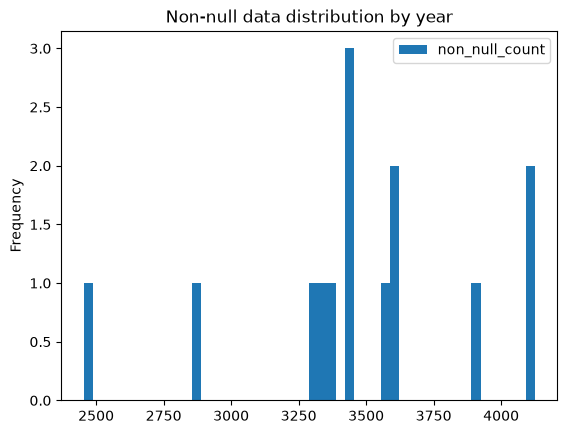

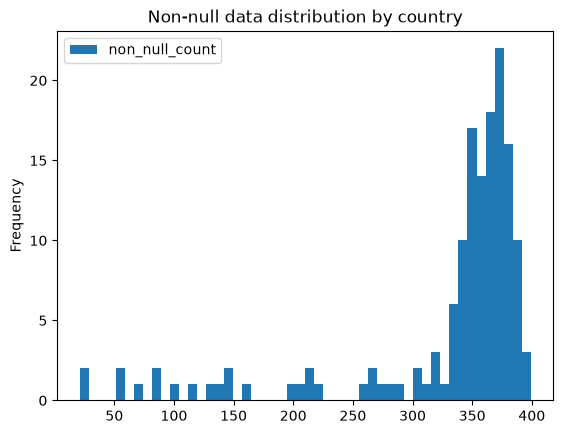

In [41]:
year_stats.plot.hist(bins=50, title="Non-null data distribution by year")
country_stats.plot.hist(bins=50, title="Non-null data distribution by country")

In [42]:
country_mode = country_stats["non_null_count"].mode()[0]
countries_w_mode = country_stats.loc[country_stats["non_null_count"] == country_mode,:].size
country_mean = country_stats["non_null_count"].mean()
country_outliers = country_stats.loc[country_stats["non_null_count"] < country_mean,:].size

print(f"Mode of non-null values per country: {country_mode}")
print(f"Mean of non-null values per country: {country_mean}")
print(f"Number of countries with same datapoints as the mode: {countries_w_mode}")
print(f"Number of countries with less data than the mean: {country_outliers}")


Mode of non-null values per country: 372
Mean of non-null values per country: 328.1418918918919
Number of countries with same datapoints as the mode: 8
Number of countries with less data than the mean: 32


What can we do from here and on? As more than the $75\%$ of all countries have more than 328 datapoints (the mean), that means that those 32 countries are dragging down the whole dataset. Here, the decision is to remove those countries:

In [43]:
outlier_country_names = country_stats.loc[country_stats["non_null_count"] < country_mean,:].index
no_country_outliers = valid_df.loc[~valid_df["Country name"].isin(outlier_country_names), :]

In [44]:
# Check only features
no_country_outliers.iloc[:, 3:20].describe()

,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,Access to electricity (% of population),Agricultural land (% of land area),Alternative and nuclear energy (% of total energy use),Expense (% of GDP),Food production index (2014-2016 = 100),Forest area (% of land area),Fossil fuel energy consumption (% of total),GDP growth (annual %),GDP per capita growth (annual %),"Government expenditure on education, total (% of GDP)"
count,811.000000,811.000000,809.000000,811.000000,804.000000,805.000000,811.000000,1389.000000,1389.000000,1330.000000,1127.000000,1273.000000,1389.000000,406.000000,1619.000000,1614.000000,1200.000000
mean,1.300798,1.116561,0.568023,0.632741,0.149813,0.150600,1.764963,85.117927,41.938148,11.871917,26.590442,102.891665,31.383438,62.604196,3.136554,1.947118,4.267929
std,0.448470,0.349443,0.220447,0.198609,0.082239,0.123801,0.651481,26.012487,18.886916,15.201130,10.965907,13.019512,19.385367,27.122739,3.916843,3.819035,1.576066
min,0.108330,0.058000,0.017000,0.083944,0.003000,0.000830,-0.222000,4.100000,0.919220,0.010000,3.695458,62.400000,0.287611,-61.378855,-28.758584,-22.745681,0.319069
25%,0.982509,0.877500,0.409000,0.500000,0.092000,0.063000,1.353000,85.200000,29.759704,1.912500,17.112814,96.530000,14.458775,45.324703,1.501291,0.421408,3.175590
50%,1.333000,1.151000,0.568000,0.621000,0.138688,0.114826,1.809000,99.800000,42.849672,6.470000,25.944683,101.320000,31.860334,70.116690,3.339203,2.121960,4.191885
75%,1.668500,1.399839,0.727000,0.750000,0.197000,0.193000,2.203559,100.000000,53.875439,15.935000,34.855835,107.820000,44.871164,84.293646,5.261190,3.977903,5.277047
max,2.209000,1.840000,1.137814,1.147000,0.569814,0.587000,3.482000,100.000000,82.996229,100.000000,65.560022,183.450000,81.912168,99.887114,24.623986,23.452027,10.826554


In [45]:
no_country_outliers.iloc[:, 20:-1].describe()

,"Inflation, consumer prices (annual %)","Life expectancy at birth, total (years)","Literacy rate, adult total (% of people ages 15 and above)",Net migration,"PM2.5 air pollution, population exposed to levels exceeding WHO guideline value (% of total)",Population growth (annual %),Population in urban agglomerations of more than 1 million (% of total population),Population living in areas where elevation is below 5 meters (% of total population),Population living in slums (% of urban population),Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population),"Prevalence of HIV, total (% of population ages 15-49)","Primary completion rate, total (% of relevant age group)",Renewable electricity output (% of total electricity output),Rural population (% of total population),"School enrollment, primary and secondary (gross), gender parity index (GPI)",Terrestrial and marine protected areas (% of total territorial area),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
count,1602.000000,1505.000000,416.000000,1.614000e+03,682.000000,1621.000000,1356.000000,89.000000,543.000000,746.000000,1274.000000,1087.000000,1120.000000,1607.000000,794.000000,1377.000000,1615.000000,1621.000000
mean,6.020853,73.158395,84.674309,4.467398e+03,90.147941,1.162169,25.048480,5.151249,25.481832,6.783244,1.440738,91.207666,37.571072,37.893083,0.990334,15.283588,6.939892,62.434186
std,19.483709,7.760625,17.751133,2.986096e+05,24.798888,1.327418,16.398944,7.453999,24.357144,13.904898,3.461624,14.451995,29.214670,20.262933,0.058379,10.933065,5.297931,20.477790
min,-4.763860,50.426000,22.309999,-5.699445e+06,0.258944,-8.423008,3.502841,0.013799,0.011010,0.100000,0.100000,33.537209,0.002155,4.061410,0.678300,0.500000,0.119000,15.552315
25%,1.597237,67.807000,78.017498,-2.475975e+04,97.918248,0.299667,13.739023,1.441168,1.482545,0.400000,0.100000,88.177069,12.753898,21.881062,0.980115,5.500000,3.573500,50.984741
50%,3.309137,74.576000,93.090000,-2.993000e+03,100.000000,1.129111,19.984876,2.611095,16.477140,1.200000,0.300000,96.824623,30.395412,35.679255,1.000435,14.000000,5.244000,64.524401
75%,6.240281,79.978049,96.302500,2.737475e+04,100.000000,1.966369,31.864083,6.004662,47.283200,5.550000,0.900000,99.482067,61.292848,49.093069,1.017518,22.100000,8.530500,78.648806
max,557.201817,84.560000,100.000000,1.889129e+06,100.000000,9.992305,100.000000,53.688095,92.496970,81.600000,22.800000,128.295324,99.997377,84.447685,1.175880,59.700000,34.007000,100.000000


In [46]:
# Check year and happiness score features
no_country_outliers.iloc[:, :3].describe()

,Year,Life evaluation (3-year average)
count,1621.000000,1621.000000
mean,2018.358421,5.603214
std,4.255915,1.111581
min,2011.000000,2.392000
25%,2015.000000,4.700000
50%,2019.000000,5.674100
75%,2022.000000,6.455000
max,2025.000000,7.856000


We have a much better dataset now, as we can observe that no feature holds a minimum of $0$, which has been deemed as `NaN` data (given the nature of the features).
Let's save our progress:

In [47]:
save_csv("no_country_outliers", no_country_outliers)

File already exists. Skiping!


Now, we shall recall that there where some countries with missing data, and we haven't dealt with that problem yet. As most outliers are now gone, we can compute the mean for each country, as it makes sense that indicators move around the mean throughout the years. Let's replace missing data, per country, by the feature's mean. But before doing so, let's check our current features:

In [48]:
non_null = no_country_outliers.notna().sum(axis=0)
non_null

Year                                                                                            1621
Country name                                                                                    1621
Life evaluation (3-year average)                                                                1621
Explained by: Log GDP per capita                                                                 811
Explained by: Social support                                                                     811
Explained by: Healthy life expectancy                                                            809
Explained by: Freedom to make life choices                                                       811
Explained by: Generosity                                                                         804
Explained by: Perceptions of corruption                                                          805
Dystopia + residual                                                                        

There are still features with a low count of non-null values! As maybe I overlooked them before, let's take a more dynamic approach to removing them: Let's stablish an elimination threshold:

In [49]:
non_null.describe()

count      39.000000
mean     1167.974359
std       428.297639
min        89.000000
25%       810.000000
50%      1274.000000
75%      1610.500000
max      1621.000000
dtype: float64

In [50]:
# Let's take the mean as a threshold
elimination_threshold = non_null.mean()

# Get the columns I want to keep. They contain essential columns as Year,
# Country name, and Life eval... as I already know they surpass the threshold.
keepers = non_null[non_null >= elimination_threshold].index

eliminated_df = no_country_outliers.loc[:, keepers]
eliminated_df.columns

Index(['Year', 'Country name', 'Life evaluation (3-year average)',
       'Access to electricity (% of population)',
       'Agricultural land (% of land area)',
       'Alternative and nuclear energy (% of total energy use)',
       'Food production index (2014-2016 = 100)',
       'Forest area (% of land area)', 'GDP growth (annual %)',
       'GDP per capita growth (annual %)',
       'Government expenditure on education, total (% of GDP)',
       'Inflation, consumer prices (annual %)',
       'Life expectancy at birth, total (years)', 'Net migration',
       'Population growth (annual %)',
       'Population in urban agglomerations of more than 1 million (% of total population)',
       'Prevalence of HIV, total (% of population ages 15-49)',
       'Rural population (% of total population)',
       'Terrestrial and marine protected areas (% of total territorial area)',
       'Unemployment, total (% of total labor force) (modeled ILO estimate)',
       'Urban population (% of tot

In [51]:
eliminated_df.info()

<class 'pandas.DataFrame'>
Index: 1621 entries, 0 to 1895
Data columns (total 22 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   Year                                                                               1621 non-null   int64  
 1   Country name                                                                       1621 non-null   str    
 2   Life evaluation (3-year average)                                                   1621 non-null   float64
 3   Access to electricity (% of population)                                            1389 non-null   float64
 4   Agricultural land (% of land area)                                                 1389 non-null   float64
 5   Alternative and nuclear energy (% of total energy use)                             1330 non-null   float64
 6   Food pro

Much better! Let's check a known problematic set of rows:

In [52]:
eliminated_df.loc[eliminated_df["Country name"] == "India", :].head()

,Year,Country name,Life evaluation (3-year average),Access to electricity (% of population),Agricultural land (% of land area),Alternative and nuclear energy (% of total energy use),Food production index (2014-2016 = 100),Forest area (% of land area),GDP growth (annual %),GDP per capita growth (annual %),...,"Life expectancy at birth, total (years)",Net migration,Population growth (annual %),Population in urban agglomerations of more than 1 million (% of total population),"Prevalence of HIV, total (% of population ages 15-49)",Rural population (% of total population),Terrestrial and marine protected areas (% of total territorial area),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population),non_null_count
104,2025,India,4.536,NaN,NaN,NaN,NaN,NaN,7.566662,6.616569,...,NaN,-495753.0,0.887184,16.962143,NaN,64.310844,4.5,4.219,35.689156,20
237,2024,India,4.389,NaN,NaN,NaN,NaN,NaN,7.099279,6.149574,...,72.235,-630830.0,0.890707,16.711134,0.2,64.621103,4.5,4.173,35.378897,23
377,2023,India,4.054,99.5,60.060406,4.07,NaN,24.539030,7.210225,6.267418,...,72.003,-979179.0,0.883290,16.458523,NaN,64.932308,4.4,4.172,35.067692,26
505,2022,India,4.036,99.2,60.055586,4.25,127.82,24.449497,7.609365,6.762386,...,71.698,-1353478.0,0.790201,16.202587,NaN,65.244433,4.4,4.822,34.755567,29
637,2021,India,3.777,99.6,60.050765,4.24,126.11,24.359694,9.689592,8.790934,...,67.282,-348916.0,0.822648,15.930277,NaN,65.557448,4.4,6.380,34.442552,30


Okay, it is not as bad as I expected. Now we can start replacing `nan` values with the country indicator's mean:

In [53]:
# Replace missing indicator values with the mean for that country
indicator_cols = eliminated_df.iloc[:, 3:-1].columns

country_means = eliminated_df.groupby("Country name")[indicator_cols].transform("mean")

filled_df = eliminated_df.copy()
filled_df[indicator_cols] = filled_df[indicator_cols].fillna(country_means)

filled_df.isna().sum()

Year                                                                                   0
Country name                                                                           0
Life evaluation (3-year average)                                                       0
Access to electricity (% of population)                                                0
Agricultural land (% of land area)                                                     0
Alternative and nuclear energy (% of total energy use)                                84
Food production index (2014-2016 = 100)                                                0
Forest area (% of land area)                                                           0
GDP growth (annual %)                                                                  0
GDP per capita growth (annual %)                                                       0
Government expenditure on education, total (% of GDP)                                 42
Inflation, consumer p

In [54]:
filled_df.loc[eliminated_df["Country name"] == "India", :].head()

,Year,Country name,Life evaluation (3-year average),Access to electricity (% of population),Agricultural land (% of land area),Alternative and nuclear energy (% of total energy use),Food production index (2014-2016 = 100),Forest area (% of land area),GDP growth (annual %),GDP per capita growth (annual %),...,"Life expectancy at birth, total (years)",Net migration,Population growth (annual %),Population in urban agglomerations of more than 1 million (% of total population),"Prevalence of HIV, total (% of population ages 15-49)",Rural population (% of total population),Terrestrial and marine protected areas (% of total territorial area),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population),non_null_count
104,2025,India,4.536,91.691667,60.257613,3.679167,108.707273,24.031287,7.566662,6.616569,...,69.866846,-495753.0,0.887184,16.962143,0.2,64.310844,4.5,4.219,35.689156,20
237,2024,India,4.389,91.691667,60.257613,3.679167,108.707273,24.031287,7.099279,6.149574,...,72.235000,-630830.0,0.890707,16.711134,0.2,64.621103,4.5,4.173,35.378897,23
377,2023,India,4.054,99.500000,60.060406,4.070000,108.707273,24.539030,7.210225,6.267418,...,72.003000,-979179.0,0.883290,16.458523,0.2,64.932308,4.4,4.172,35.067692,26
505,2022,India,4.036,99.200000,60.055586,4.250000,127.820000,24.449497,7.609365,6.762386,...,71.698000,-1353478.0,0.790201,16.202587,0.2,65.244433,4.4,4.822,34.755567,29
637,2021,India,3.777,99.600000,60.050765,4.240000,126.110000,24.359694,9.689592,8.790934,...,67.282000,-348916.0,0.822648,15.930277,0.2,65.557448,4.4,6.380,34.442552,30


That helped quite a lot, but we still have invalid data. Now that they are just a bunch, we can drop them:

In [55]:
# Let's also drop our non_null_count utility column
clean_df = filled_df.dropna().drop(columns=["non_null_count"])
clean_df.info()

<class 'pandas.DataFrame'>
Index: 1062 entries, 2 to 1895
Data columns (total 21 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   Year                                                                               1062 non-null   int64  
 1   Country name                                                                       1062 non-null   str    
 2   Life evaluation (3-year average)                                                   1062 non-null   float64
 3   Access to electricity (% of population)                                            1062 non-null   float64
 4   Agricultural land (% of land area)                                                 1062 non-null   float64
 5   Alternative and nuclear energy (% of total energy use)                             1062 non-null   float64
 6   Food pro

Awesome! Let's save this clean dataset and continue with the exploration and visualization steps.

In [56]:
save_csv("clean_data", clean_df)

File already exists. Skiping!


# Data Exploration and Visualization
Here we'll further explore the nature of our data and get key insights. I want to explore three scenarios first: How have happiness scores evolved throughout the years, how have indicators evolved by taking their mean, and how do they correlate to life evaluation scores. 

First, lets check how have life evaluation scores evolved through the years:

In [57]:
# Utility function to save images
def save_plt(name: str):
    IMAGE_DIR = os.path.join("data", "images")
    if not os.path.exists(IMAGE_DIR):
        os.mkdir(IMAGE_DIR)
    path = os.path.join(IMAGE_DIR, f"{name}.png")
    plt.savefig(path)

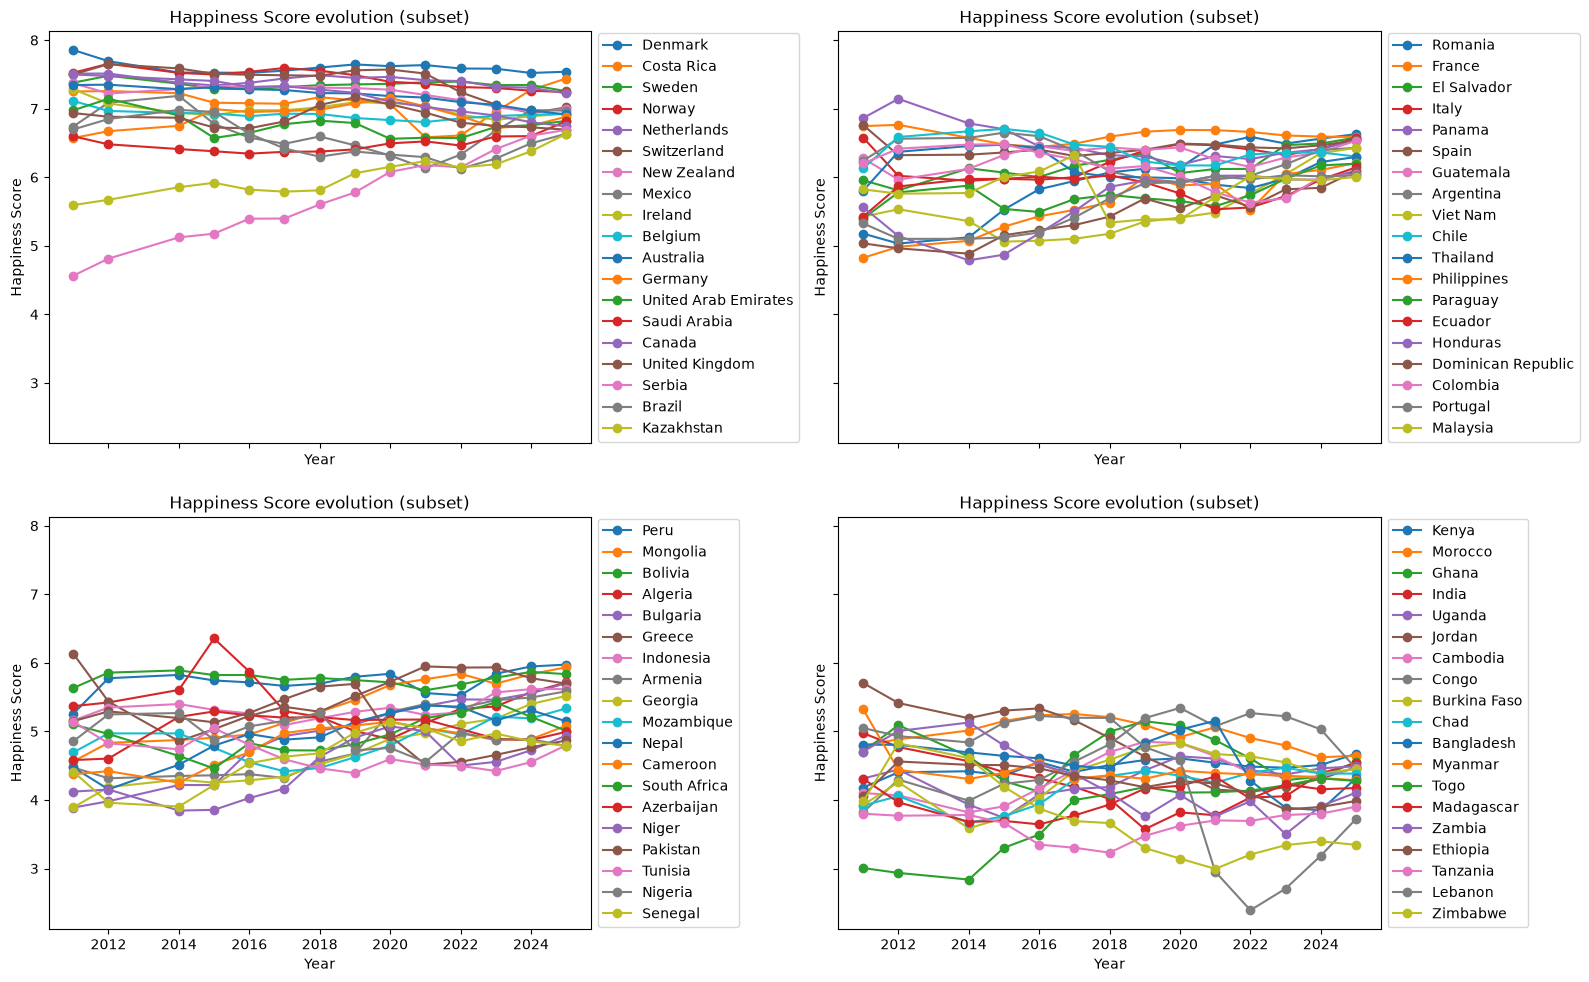

In [58]:
# Generate 4 graphs to unclutter the data
countries = clean_df["Country name"].unique()
chunk_size = len(countries) // 4
chunks = [countries[i : i + chunk_size] for i in range(0, len(countries), chunk_size)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, subset in zip(axes, chunks):
    for country in subset:
        group = clean_df.loc[clean_df["Country name"] == country].sort_values("Year")
        ax.plot(
            group["Year"],
            group["Life evaluation (3-year average)"],
            label=country,
            marker="o" # Little aid for visualization
        )

    ax.set_title("Happiness Score evolution (subset)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Happiness Score")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()

save_plt("Happiness Score evolution")
plt.show()

Some examples stick out, like Brasil and Mexico (top left), Algeria (bottom left), Viet Nam (top right), and Lebanon (bottom right). Let's check them out:

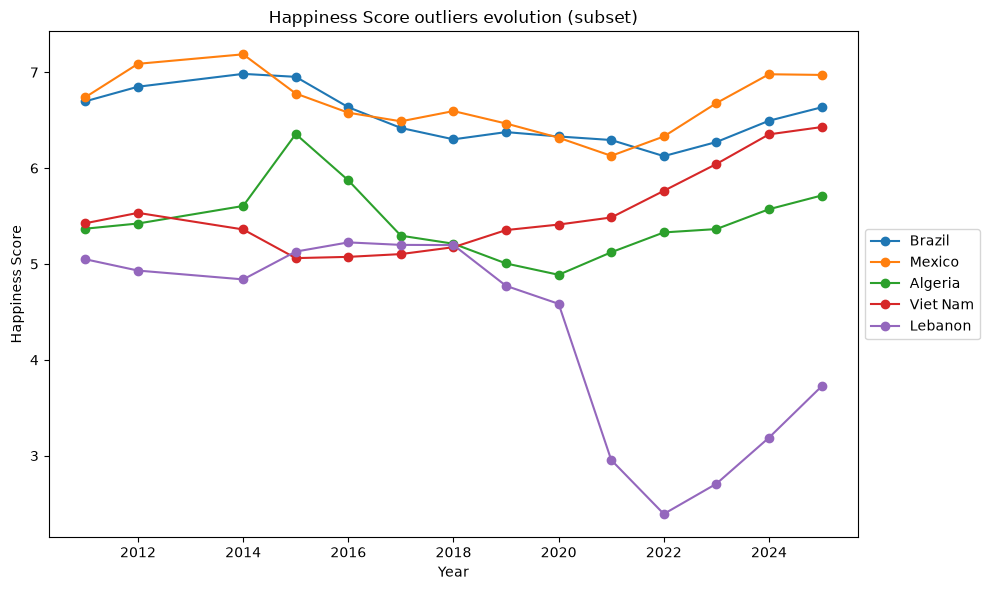

In [59]:
# Generate 4 graphs to unclutter the data
interesting_countries = ["Brazil", "Mexico", "Algeria", "Viet Nam", "Lebanon"]

fig, ax = plt.subplots(figsize=(10, 6))

for country in interesting_countries:
    group = clean_df.loc[clean_df["Country name"] == country].sort_values("Year")
    ax.plot(
        group["Year"],
        group["Life evaluation (3-year average)"],
        label=country,
        marker="o" 
    )

ax.set_title("Happiness Score outliers evolution (subset)")
ax.set_xlabel("Year")
ax.set_ylabel("Happiness Score")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
save_plt("Happiness Score outliers evolution")
plt.show()

Looking closely, only Lebanon shows an anomalous behaviour between 2019 and 2022. A quick investigation (https://en.wikipedia.org/wiki/2020_Beirut_explosion) shows that it could be related to the  the 2019's protests and the "2020 Beirut explosion" which:
> "resulted in at least 218 deaths, 7,000 injuries, and approximately 300,000 displaced people, alongside property damage estimated at US$15 billion"
>
> -- source: Wikipedia

Let's continue with our analysis: How have different indicators evolved?

In [88]:
indicators_means = clean_df.drop(columns=["Country name", "Life evaluation (3-year average)"]).groupby("Year").mean()

# Let's build 3 indicators groups, with 6 graphs each. This will equal 18 charts = 18 features
indicators = indicators_means.columns
chunk_size = len(indicators) // 3
indicators_a, indicators_b, indicators_c = [indicators[i : i + chunk_size] for i in range(0, len(indicators), chunk_size)]

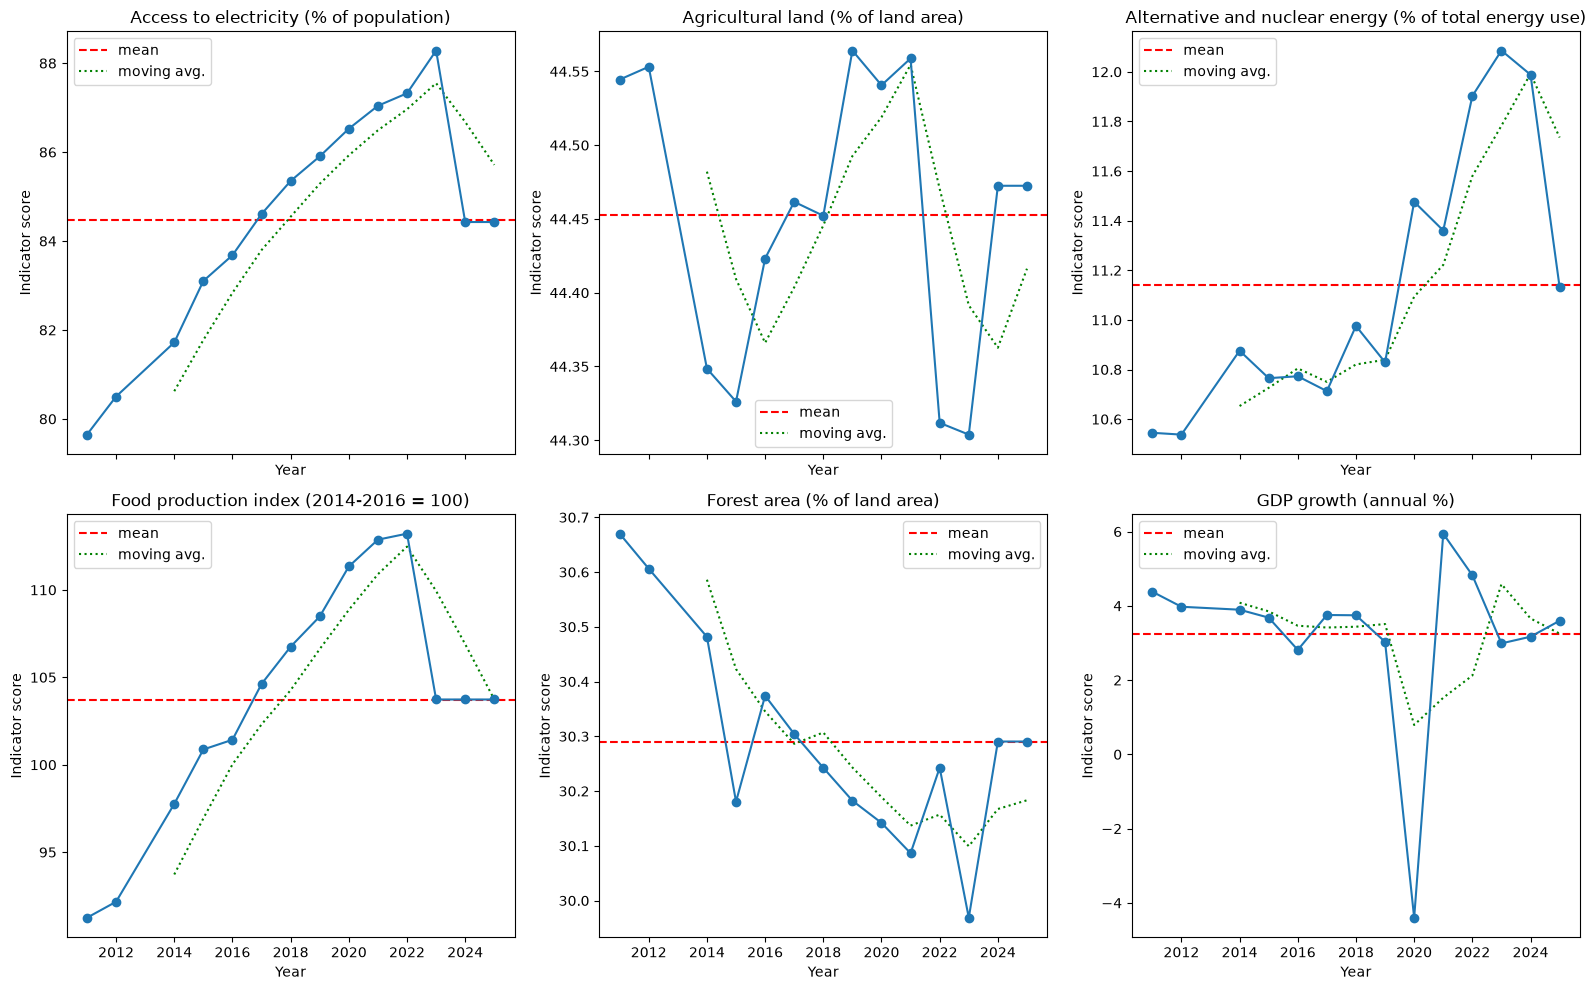

In [100]:
# Plot first group
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=False)
axes = axes.flatten()

for ax, indicator in zip(axes, indicators_a):
    # Plot the overall mean
    mean_of_mean = indicators_means[indicator].mean()
    ax.axhline(mean_of_mean, color="red", linestyle="--", label="mean")
    # Plot the moving average to better visualize trends without outliers' shift
    rolling_avg = indicators_means[indicator].rolling(3).mean()
    ax.plot(rolling_avg, color="green", linestyle="dotted", label="moving avg.")
    # Plot the actual indicators' means
    ax.plot(indicators_means[indicator], marker='o')
    ax.set_title(indicator)
    ax.set_xlabel("Year")
    ax.set_ylabel("Indicator score")
    ax.legend()

plt.tight_layout()

save_plt("Indicators' mean evolution (group A)")
plt.show()

We have already seen that general happiness tends to grow over the years. These indicators might pinpoint some of ht e most important reasons why:
- Access to electricity, the use of alternative energy sources, and food production has grown over the past 15 years, almost consistenly.
- Forest areas have decreased, and GDP growth has been relatively stable.

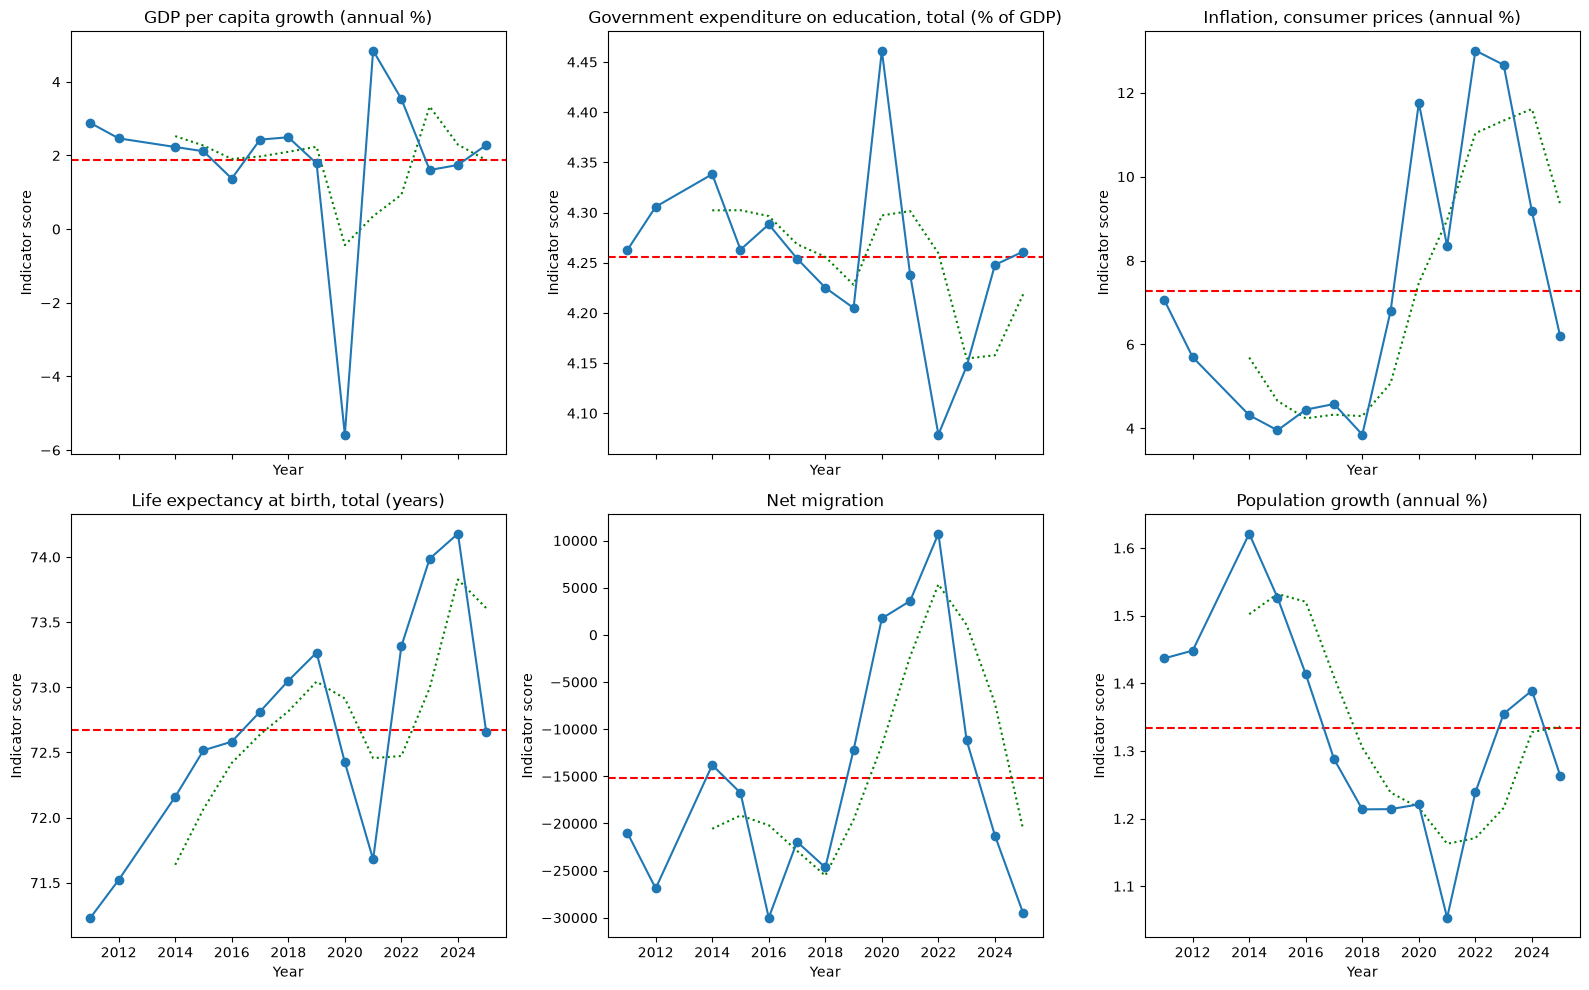

In [101]:
# Plot second group
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=False)
axes = axes.flatten()

for ax, indicator in zip(axes, indicators_b):
     # Plot the overall mean
    mean_of_mean = indicators_means[indicator].mean()
    ax.axhline(mean_of_mean, color="red", linestyle="--", label="mean")
    # Plot the moving average to better visualize trends without outliers' shift
    rolling_avg = indicators_means[indicator].rolling(3).mean()
    ax.plot(rolling_avg, color="green", linestyle="dotted", label="moving avg.")
    # Plot the actual indicators' means
    ax.plot(indicators_means[indicator], marker='o')
    ax.set_title(indicator)
    ax.set_xlabel("Year")
    ax.set_ylabel("Indicator score")

plt.tight_layout()

save_plt("Indicators' mean evolution (group B)")
plt.show()

Some insights we can get here are:
- Life expectancy tends to grow along with inflation.
- Net migration had a spike around 2018-2022.
- The rest of the indicators doesn't seem to follow a clear trend. More yearly data might be needed.

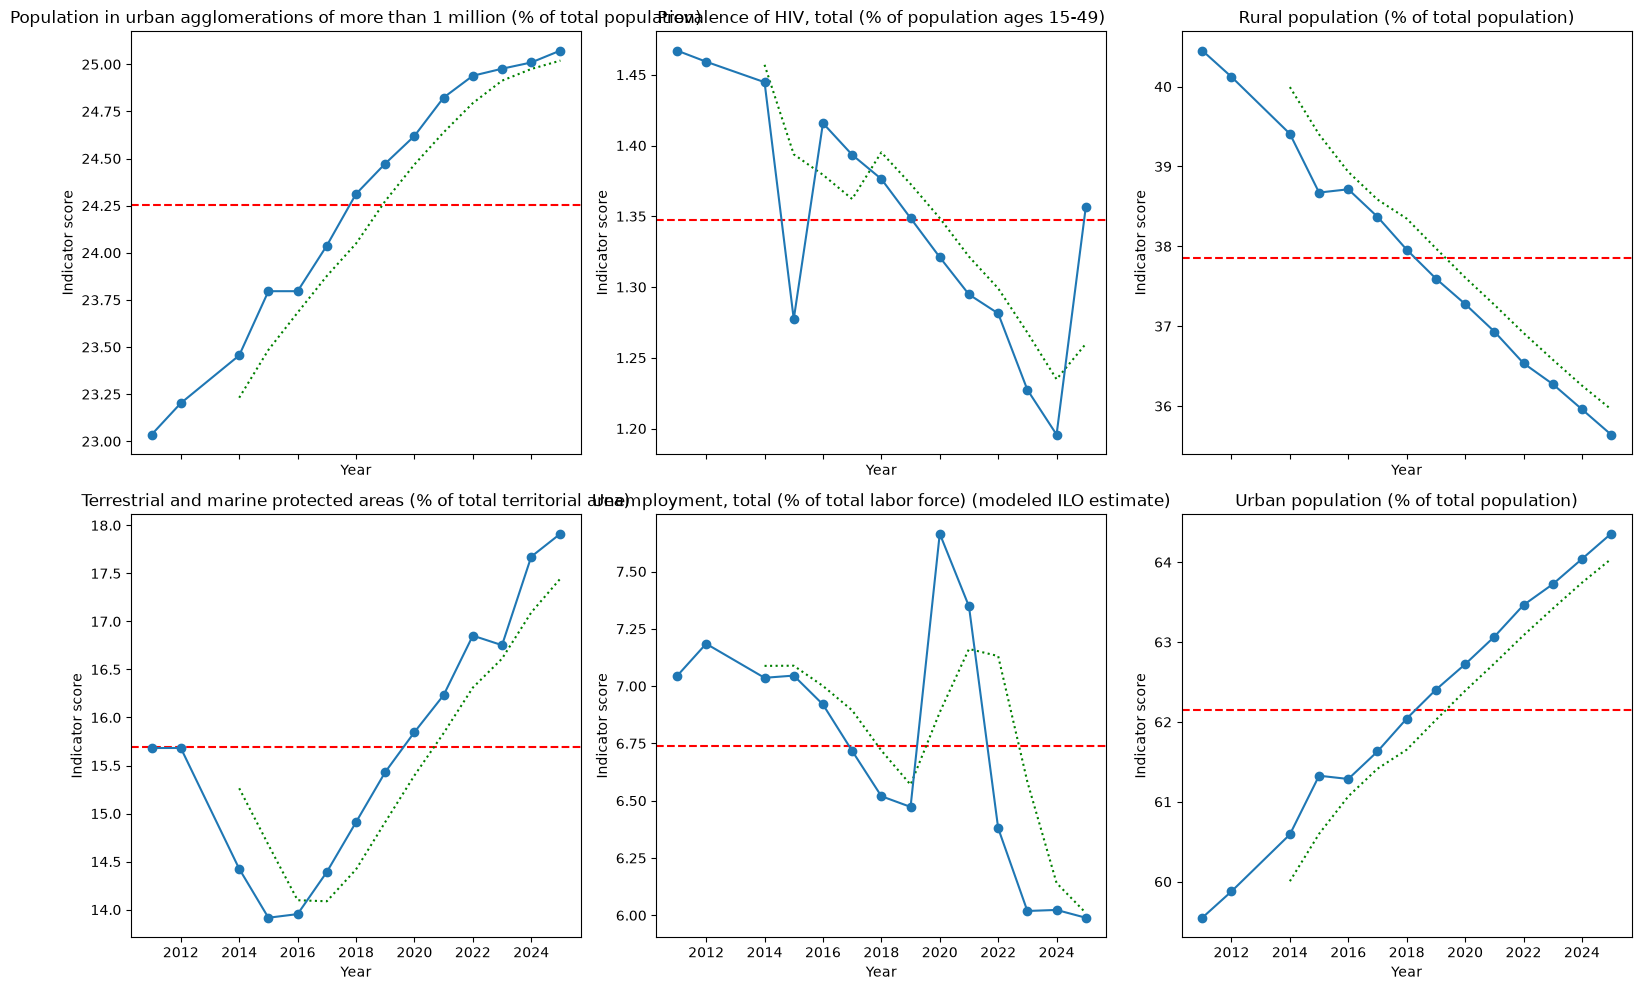

In [107]:
# Plot last group
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=False)
axes = axes.flatten()

for ax, indicator in zip(axes, indicators_c):
    # Plot the overall mean
    mean_of_mean = indicators_means[indicator].mean()
    ax.axhline(mean_of_mean, color="red", linestyle="--", label="mean")
    # Plot the moving average to better visualize trends without outliers' shift
    rolling_avg = indicators_means[indicator].rolling(3).mean()
    ax.plot(rolling_avg, color="green", linestyle="dotted", label="moving avg.")
    # Plot the actual indicators' means
    ax.plot(indicators_means[indicator], marker='o')
    ax.set_title(indicator)
    ax.set_xlabel("Year")
    ax.set_ylabel("Indicator score")

plt.tight_layout()

save_plt("Indicators' mean evolution (group C)")
plt.show()

Here we can see some of the most important (apparently) indicators:
- Population in urban agglomerations, protected areas, and overall urban populations follow a clear growth trend.
- Prevalence of HIV and rural population have decreased over the years.
- Unemployment have also decreased almost consistently, with a spike at 2019-2020.

From all these indicators, how do they correlate to happiness?

In [126]:
clean_df.select_dtypes(['number']).shape[1]

20

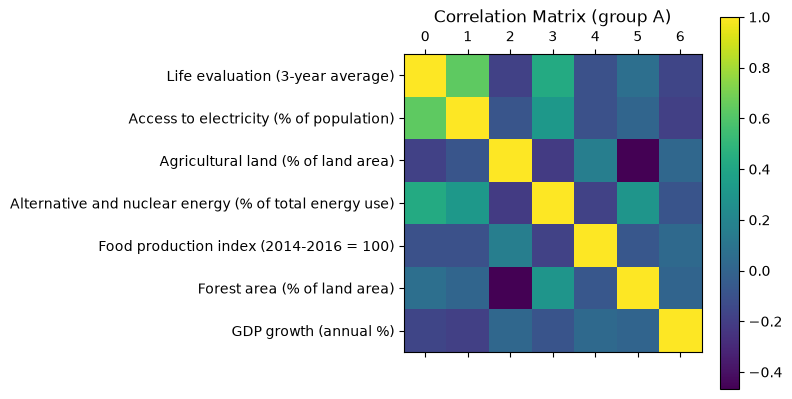

In [134]:
indicators_a_corr = clean_df.loc[:, indicators_a.insert(item="Life evaluation (3-year average)", loc=0)]
plt.matshow(indicators_a_corr.corr())

plt.yticks(range(indicators_a_corr.columns.size), indicators_a_corr.columns)
cb = plt.colorbar()
cb.ax.tick_params()
plt.title("Correlation Matrix (group A)")
save_plt("Correlation Matrix (group A)")
plt.show()

For every chart, we are most interested in the leftmost column, as it shows the correlation between every indicator and the "Life evaluation" (happiness score).

In this first correlation matrix, only access to electricity and alternative energy sources are somewhat correlated.

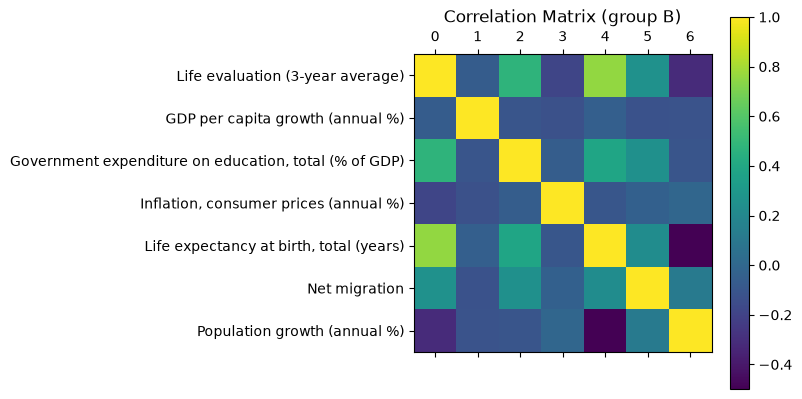

In [135]:
indicators_b_corr = clean_df.loc[:, indicators_b.insert(item="Life evaluation (3-year average)", loc=0)]
plt.matshow(indicators_b_corr.corr())

plt.yticks(range(indicators_b_corr.columns.size), indicators_b_corr.columns)
cb = plt.colorbar()
cb.ax.tick_params()
plt.title("Correlation Matrix (group B)")
save_plt("Correlation Matrix (group B)")
plt.show()

Here we can observe that the government expenditure, along with life expectancy at birth and net migration are somewhat correlated to the happiness score, whereas the population growth has an inverse relation (the higher the population growth, the lower the happiness).

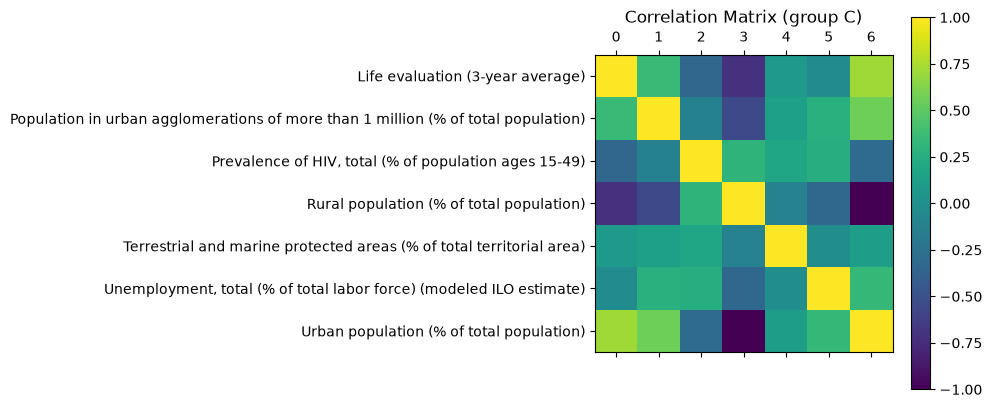

In [136]:
indicators_c_corr = clean_df.loc[:, indicators_c.insert(item="Life evaluation (3-year average)", loc=0)]
plt.matshow(indicators_c_corr.corr())

plt.yticks(range(indicators_c_corr.columns.size), indicators_c_corr.columns)
cb = plt.colorbar()
cb.ax.tick_params()
plt.title("Correlation Matrix (group C)")
save_plt("Correlation Matrix (group C)")
plt.show()

Finally, population in urban aglomerations and urban population seems to be directly proportional to the happiness score, while the rural population seems to have an inverse relation. Both protected areas and unemployment also look correlated.

If we analyse the raw scores, this is what we get:

In [140]:
indicators_a_corr.corr()["Life evaluation (3-year average)"]

Life evaluation (3-year average)                          1.000000
Access to electricity (% of population)                   0.636050
Agricultural land (% of land area)                       -0.181227
Alternative and nuclear energy (% of total energy use)    0.428268
Food production index (2014-2016 = 100)                  -0.104928
Forest area (% of land area)                              0.070899
GDP growth (annual %)                                    -0.161746
Name: Life evaluation (3-year average), dtype: float64

In [141]:
indicators_b_corr.corr()["Life evaluation (3-year average)"]

Life evaluation (3-year average)                         1.000000
GDP per capita growth (annual %)                        -0.061396
Government expenditure on education, total (% of GDP)    0.475383
Inflation, consumer prices (annual %)                   -0.185703
Life expectancy at birth, total (years)                  0.756388
Net migration                                            0.259665
Population growth (annual %)                            -0.311604
Name: Life evaluation (3-year average), dtype: float64

In [142]:
indicators_c_corr.corr()["Life evaluation (3-year average)"]

Life evaluation (3-year average)                                                     1.000000
Population in urban agglomerations of more than 1 million (% of total population)    0.345956
Prevalence of HIV, total (% of population ages 15-49)                               -0.340926
Rural population (% of total population)                                            -0.715787
Terrestrial and marine protected areas (% of total territorial area)                 0.077424
Unemployment, total (% of total labor force) (modeled ILO estimate)                 -0.034898
Urban population (% of total population)                                             0.715787
Name: Life evaluation (3-year average), dtype: float64

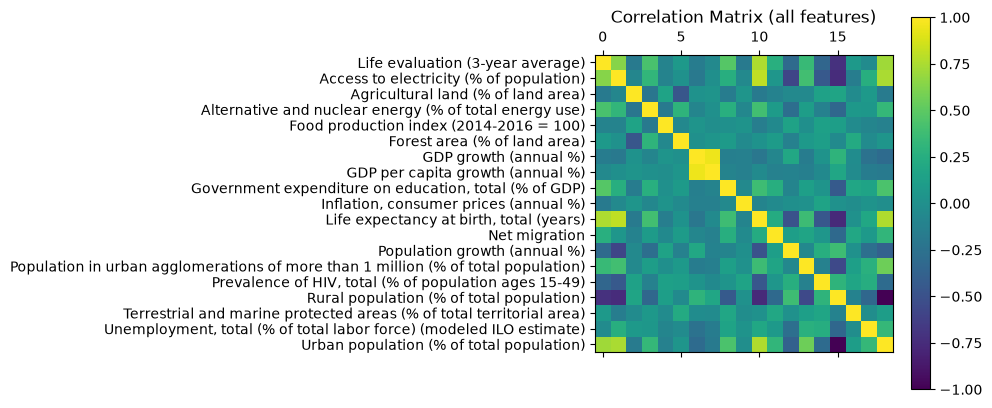

In [267]:
whole_correlation = clean_df.iloc[:, 2:]
plt.matshow(whole_correlation.corr())

plt.yticks(range(whole_correlation.columns.size), whole_correlation.columns)
cb = plt.colorbar()
cb.ax.tick_params()
plt.title("Correlation Matrix (all features)")
save_plt("Correlation Matrix (all features)")
plt.show()

Looking at the raw scores, we keep our observations as this:
- Highly Directly proportional: Access to electricity, Life expectancy at birth, Urban population
- Highly Inversely proportional: Rural population

- Somewhat Directly proportional: Alternative and nuclear energy, Government expenditure on education, Population in urban agglomerations
- Somewhat Inversely proportional: Population growth, Prevalence of HIV

In [148]:
most_relevant_indicators = ['Access to electricity (% of population)',
       'Life expectancy at birth, total (years)',
       'Urban population (% of total population)',
       'Rural population (% of total population)',
       'Alternative and nuclear energy (% of total energy use)',
       'Government expenditure on education, total (% of GDP)',
       'Population in urban agglomerations of more than 1 million (% of total population)',
       'Population growth (annual %)',
       'Prevalence of HIV, total (% of population ages 15-49)']

# Model training
Now we are ready to start implementing a preprocessing and training pipeline for our ML models.
Our target is the "Happiness Score", and we'll use all of our features stored in the `clean_df` dataframe.

Later on we'll be doing some feature engineering to improve our model's scores.

Since Linear Regression is quite sensitive to outliers and scale, we must scale our data by normalizing or standardizing it.

First of all, we must divide our dataset into a training, validation, and testing sets. Then, we can preprocess the data by normalizing it and, finally, train some models.

Keep in mind that some features are no longer needed, like the country name. Also, we'll assume every country at any given year to be a snapshot of a nation with a set of current indicators. This way, we can dump both the nation's name and the year of the indicators.

In [151]:
data = clean_df.drop(columns=["Country name", "Year"])

# We will also change the predictor's name from "Life evaluation..." to "y":
data.rename(columns={"Life evaluation (3-year average)": "y"}, inplace=True)

save_csv("training_data_v1", data)
data.head()

,y,Access to electricity (% of population),Agricultural land (% of land area),Alternative and nuclear energy (% of total energy use),Food production index (2014-2016 = 100),Forest area (% of land area),GDP growth (annual %),GDP per capita growth (annual %),"Government expenditure on education, total (% of GDP)","Inflation, consumer prices (annual %)","Life expectancy at birth, total (years)",Net migration,Population growth (annual %),Population in urban agglomerations of more than 1 million (% of total population),"Prevalence of HIV, total (% of population ages 15-49)",Rural population (% of total population),Terrestrial and marine protected areas (% of total territorial area),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
2,7.539,100.000000,65.829963,9.230769,100.220000,15.544450,2.928433,2.377287,7.375067,1.893674,81.071857,22103.0,0.536904,23.309978,0.100000,11.154156,23.8,5.529,88.845844
3,7.439,99.658333,34.082229,38.885385,99.362727,58.582537,4.560335,4.092823,6.476988,-0.073671,79.957000,1000.0,0.448125,29.160675,0.492308,20.273186,28.2,6.843,79.726814
4,7.255,100.000000,7.402878,49.590000,97.308182,68.726008,1.543164,1.285286,7.510835,0.679869,82.630394,47079.0,0.254281,16.399239,0.100000,10.922132,15.9,8.694,89.077868
5,7.242,100.000000,2.704635,44.460769,99.499091,33.325533,1.085282,0.390027,7.360539,3.055625,82.533959,29798.0,0.690166,19.882549,0.100000,16.429421,5.4,4.637,83.570579
6,7.223,100.000000,54.167587,4.472308,99.155455,10.949689,1.784632,1.254833,5.282758,3.259577,81.606567,104681.0,0.521870,12.248441,0.191667,4.061410,29.8,3.874,95.938590


In [154]:
from sklearn.model_selection import train_test_split

# Separate features from target
X, y = data.iloc[:, 1:], data.iloc[:, 0]

# Divide our data using Scikit-Learn method
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    shuffle=True,
                                                    random_state=42)


Let's get some preprocessing functions:

In [156]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

std_scaler = StandardScaler()

We'll select some common regression models and build pipelines around them:

In [190]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

std_step = ("Standardize", std_scaler)

linear_model = ("Linear", LinearRegression())
stochastic_model = ("Stochastic", SGDRegressor())
svm_model = ("SVM", SVR())
tree_model = ("Decision Tree", DecisionTreeRegressor())
random_forest_model = ("Random Forest", RandomForestRegressor())

## Cross validation and fine tuning
We cannot forget about validating our results! And as we are doing this, we could benefit from using Grid Search to get the best possible results.

Also, automated feature selection and polinomial features might prove to be helpful.

In [235]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features extraction step
poly_feat_step = ("poly_feat", PolynomialFeatures())

# Create feature selection step
feat_select_step = ("feat_select", SelectKBest(f_regression))

# Define how data will be splitted for cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Define the GridSearch parameters to be tweaked
param_grid = {
    # Linear vs quadratic regressions. Must not be a very complicated formula, as we do not have much data and this might cause overfitting!    
    'poly_feat__degree': [1, 2],
    # Some common values. It'll also reduce the number of features being used. Useful since we already saw that only a handful of them do correlate with happiness scores.
    "feat_select__k": [3, 5, 8, 10], 
}

# How results will be scored and tested
scoring = ["neg_root_mean_squared_error", "r2"] # RMSE and R2 as standards

## Linear regression
Our most basic model: a linear regressor.

In [236]:
linear_pipe = Pipeline([
    std_step,           # Standarization
    poly_feat_step,     # Polynomial features
    feat_select_step,   # Feature selection
    linear_model        # Linear regression model
])

linear_grid_search = GridSearchCV(linear_pipe,
                                  param_grid,
                                  cv=cv,
                                  scoring=scoring,
                                  refit="neg_root_mean_squared_error",
                                  return_train_score=True)

Now we can train our first model:

In [237]:
linear_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'feat_select__k': [3, 5, ...], 'poly_feat__degree': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['neg_root_mean_squared_error', 'r2']"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.Ho

In [238]:
# Results
def show_results(grid_search):
    cols = {
        "params": "Best params",
        "mean_train_r2": "Best mean train R2",
        "mean_test_r2": "Best mean validation R2",
        "mean_train_neg_root_mean_squared_error": "Best mean train RMSE",
        "mean_test_neg_root_mean_squared_error": "Best mean validation RMSE",
    }
    # Sort by validation RMSE (best models at top)
    summary = pd.DataFrame(grid_search.cv_results_)[cols.keys()].iloc[[grid_search.best_index_], :].rename(columns=cols)
    summary["Best mean train RMSE"] = -summary["Best mean train RMSE"]
    summary["Best mean validation RMSE"] = -summary["Best mean validation RMSE"]

    return summary

In [239]:
show_results(linear_grid_search)

,Best params,Best mean train R2,Best mean validation R2,Best mean train RMSE,Best mean validation RMSE
7,"{'feat_select__k': 10, 'poly_feat__degree': 2}",0.669225,0.655366,0.645666,0.654873


These results are not so bad: Our model has an RMSE of around $0.65$. Note that the best results were obtained with the highest feature selection's K value and the highest polynomial degree.

It also shows that there is no apparent overfitting or underfitting, as the scores obtained in both training and validation are quite similar.

It might be worth our time adding more options to the param grid and training again:

In [240]:
param_grid = {
    'poly_feat__degree': [1, 2, 3],
    "feat_select__k": [3, 5, 8, 10, 12, 15], 
}

linear_grid_search = GridSearchCV(linear_pipe,
                                  param_grid,
                                  cv=cv,
                                  scoring=scoring,
                                  refit="neg_root_mean_squared_error",
                                  return_train_score=True)

linear_grid_search.fit(X_train, y_train)

show_results(linear_grid_search)

,Best params,Best mean train R2,Best mean validation R2,Best mean train RMSE,Best mean validation RMSE
16,"{'feat_select__k': 15, 'poly_feat__degree': 2}",0.715169,0.69979,0.598903,0.611079


Error was minimized a little, but this is not enough.
Once again, let's modify our param_grid with what we already know performs best:

In [241]:
param_grid = {
    'poly_feat__degree': [1, 2, 3],
    "feat_select__k": [8, 10, 12, 15, 18, 20], 
}

linear_grid_search = GridSearchCV(linear_pipe,
                                  param_grid,
                                  cv=cv,
                                  scoring=scoring,
                                  refit="neg_root_mean_squared_error",
                                  return_train_score=True)

linear_grid_search.fit(X_train, y_train)

show_results(linear_grid_search)

c:\Users\vicen\Study\DS\midterm_coursework\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=19. All the features will be returned.
  warnings.warn(
c:\Users\vicen\Study\DS\midterm_coursework\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=19. All the features will be returned.
  warnings.warn(
c:\Users\vicen\Study\DS\midterm_coursework\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=19. All the features will be returned.
  warnings.warn(
c:\Users\vicen\Study\DS\midterm_coursework\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=19. All the features will be returned.
  warnings.warn(
c:\Users\vicen\Study\DS\midterm_coursework\.venv\Lib\site-packages\sklearn\feature_selection\_univariate

,Best params,Best mean train R2,Best mean validation R2,Best mean train RMSE,Best mean validation RMSE
16,"{'feat_select__k': 20, 'poly_feat__degree': 2}",0.743729,0.716736,0.568259,0.590788


Some important notes here:
- The model gets better results by using every feature available: $19$. Note that even if we defined a feature selection of 20, a warning was printed telling us that it will use $19$ instead (because there are up to $19$)!
- We currently only have $19$ features to work with, and we might do some feature engineering later to add more information.
- The model still gets better results with a polynomial degree of $2$.
- The $R^2$ kept improving while the $RMSE$ got stuck around $0.60$.

Also, there migth be some overfitting. Not to much so we need to worry about it, but it started to happen.

Let's keep going by training other models. This way we might get a better understanding of the problem at hand to later start dooing some more feature engineering.

## Stochastic Regression

In [242]:
stochastic_pipe = Pipeline([std_step, poly_feat_step, feat_select_step, stochastic_model])

param_grid = {
    'poly_feat__degree': [1, 2, 3],
    # Replace 18 and 20 for only 19, as it's the maximum number of features we currently have
    "feat_select__k": [8, 10, 12, 15, 19], 
}

stochastic_grid_search = GridSearchCV(stochastic_pipe,
                                    param_grid,
                                    cv=cv,
                                    scoring=scoring,
                                    refit="neg_root_mean_squared_error",
                                    return_train_score=True)

stochastic_grid_search.fit(X_train, y_train)

show_results(stochastic_grid_search)

,Best params,Best mean train R2,Best mean validation R2,Best mean train RMSE,Best mean validation RMSE
13,"{'feat_select__k': 19, 'poly_feat__degree': 2}",0.729777,0.696638,0.583543,0.612623


Well, it performed similarly to our linear model.

## Support Vector Machine

In [243]:
svm_pipe = Pipeline([std_step, poly_feat_step, feat_select_step, svm_model])

# We can keep our param_grid unchanged
svm_grid_search = GridSearchCV(svm_pipe,
                                param_grid,
                                cv=cv,
                                scoring=scoring,
                                refit="neg_root_mean_squared_error",
                                return_train_score=True)

svm_grid_search.fit(X_train, y_train)

show_results(svm_grid_search)

,Best params,Best mean train R2,Best mean validation R2,Best mean train RMSE,Best mean validation RMSE
12,"{'feat_select__k': 19, 'poly_feat__degree': 1}",0.917109,0.852472,0.323074,0.427945


Those're the best $RMSE$ and $R^2$ scores so far!

## Decision Tree

In [244]:
tree_pipe = Pipeline([std_step, poly_feat_step, feat_select_step, tree_model])

tree_grid_search = GridSearchCV(tree_pipe,
                                param_grid,
                                cv=cv,
                                scoring=scoring,
                                refit="neg_root_mean_squared_error",
                                return_train_score=True)

tree_grid_search.fit(X_train, y_train)

show_results(tree_grid_search)

,Best params,Best mean train R2,Best mean validation R2,Best mean train RMSE,Best mean validation RMSE
7,"{'feat_select__k': 12, 'poly_feat__degree': 2}",1.0,0.856816,-0.0,0.419288


Quite similar to the SVM, but note that it uses fewer features!
What is interesting here is the difference between the training set scores and the validation ones. It was most certainly overfitting the training data.

## Random Forest
As an ensemble model, we'll have to wait a little bit longer. This is because ensembles are combinations of several models, in this case of decision trees.

In [245]:
random_forest_pipe = Pipeline([std_step, poly_feat_step, feat_select_step, random_forest_model])

random_forest_grid_search = GridSearchCV(random_forest_pipe,
                                param_grid,
                                cv=cv,
                                scoring=scoring,
                                refit="neg_root_mean_squared_error",
                                return_train_score=True)

random_forest_grid_search.fit(X_train, y_train)

show_results(random_forest_grid_search)

,Best params,Best mean train R2,Best mean validation R2,Best mean train RMSE,Best mean validation RMSE
6,"{'feat_select__k': 12, 'poly_feat__degree': 1}",0.988707,0.920704,0.119239,0.31381


Ensemble models are known for outperforming simpler models, and this is no exception: We've got our best model so far, with the minimum error and maximum $R^2$ yet.

Also, this model is not overfitting the data while keeping both the feature selection and polynomial degree to a minimum: It's a weird combination of a powerful model with the simplest hyperparameters.

Let's save our models for archiving purposes now, as the first round of training is done.

In [247]:
def save_model(model_name: str, grid_search):
    RESULTS_PATH = os.path.join("output", "results")
    MODELS_PATH = os.path.join("output", "models")
    
    if not os.path.exists(RESULTS_PATH):
        os.makedirs(RESULTS_PATH)
    
    if not os.path.exists(MODELS_PATH):
        os.makedirs(MODELS_PATH)
    
    estimator = grid_search.best_estimator_
    results = pd.DataFrame(grid_search.cv_results_)
    
    joblib.dump(estimator, os.path.join(MODELS_PATH, f"{model_name}.pkl"))
    results.to_csv(os.path.join(RESULTS_PATH, f"{model_name}_cv_results.csv"), index=False)

In [248]:
results = {
    "linear_model_v1": linear_grid_search,
    "stochastic_model_v1": stochastic_grid_search,
    "svm_model_v1": svm_grid_search,
    "tree_model_v1": tree_grid_search,
    "random_forest_model_v1": random_forest_grid_search,
}

for model_name, grid_search in results.items():
    save_model(model_name, grid_search)

# Preliminary results exploration
Let's see what made our random forest model so successful.

In [255]:
best_pipe = random_forest_grid_search.best_estimator_

model = best_pipe.named_steps["Random Forest"]
poly = best_pipe.named_steps["poly_feat"]
selector = best_pipe.named_steps["feat_select"]

original_feature_names = X_train.columns.tolist()
poly_feature_names = poly.get_feature_names_out(original_feature_names)

selected_indices = selector.get_support(indices=True)
final_feature_names = [poly_feature_names[i] for i in selected_indices]

importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": final_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
5,"Life expectancy at birth, total (years)",0.507675
0,Access to electricity (% of population),0.165415
9,"Prevalence of HIV, total (% of population ages...",0.066922
7,Population growth (annual %),0.045524
8,Population in urban agglomerations of more tha...,0.042398
10,Rural population (% of total population),0.031437
11,Urban population (% of total population),0.030246
3,"Government expenditure on education, total (% ...",0.028558
4,"Inflation, consumer prices (annual %)",0.023081
2,Alternative and nuclear energy (% of total ene...,0.020672


Those are great results! We can see that the most important features selected by our winner pipeline are life expectancy, access to electricity, and to a lesser grade, prevalence of HIV.

How can we enhance our models through feature engineering?

Here are some points to consider:
- Rural and urban populations are highly correlated, so we can drop one of them (you can already see that our model gives them a similar importance) and/or make a ratio as a new feature.
- Population in urban agglomerations and urban population are also highly correlated.
- Higher expenditure in education might affect the prevalence of HIV.
- Higher access to electricity and basic services can improve life expectancy and, therefore, population growth.
- Higher urban population is correlated to access to electricity too.
- Inflation might correlate to a higher expenditure capacity (GDP)
- Agricultural land have a direct impact on food production.
- Migration affects population growth.


Let's create some new features!

# Feature Engineering
We'll create another step for our pipelines where we engineer new features before values have been scaled.

In [307]:
from sklearn.preprocessing import FunctionTransformer

def engineer_features(df: pd.DataFrame):
    
    enhanced_df = pd.DataFrame(df, copy=True)

    # Let's add a urban/rural ratio
    enhanced_df["Urban to rural ratio"] = enhanced_df["Urban population (% of total population)"] /     (enhanced_df["Rural population (% of total population)"] + 1e-6)

    # Urban efficiency and overpopulation feature
    enhanced_df["Urban efficiency"] = enhanced_df["Population in urban agglomerations of more than 1 million (% of total population)"] / (enhanced_df["Urban population (% of total population)"] + 1e-6)

    # Sex education efficiency feature using np.log1p to handle different scales and zero-division
    enhanced_df["Sex-Ed efficiency"] = np.log1p(enhanced_df["Government expenditure on education, total (% of GDP)"]) - np.log1p(enhanced_df["Prevalence of HIV, total (% of population ages 15-49)"])

    # Economic stability based on inflation and GDP
    enhanced_df["Economic stability"] = enhanced_df["GDP per capita growth (annual %)"] - enhanced_df["Inflation, consumer prices (annual %)"]

    # Drop redundant columns
    enhanced_df.drop(columns=["Urban population (% of total population)"], inplace=True)

    return enhanced_df

engineer_transformer = FunctionTransformer(engineer_features, validate=False)

Let's make a generic pipeline factory:

In [308]:
def make_pipeline(model):

    pipeline = Pipeline([
        ("feat_eng", engineer_transformer),         # Feature engineering
        ("std_scaler", StandardScaler()),           # Standarization
        ("poly_feat", PolynomialFeatures()),        # Polynomial features
        ("feat_select", SelectKBest(f_regression)), # Feature selection
        ("model", model)                            # Linear regression model
    ])
    return pipeline

Let's also create the whole training and results saving process:

In [309]:
def make_grid_search(model) -> GridSearchCV:
    
    pipeline = make_pipeline(model)

    param_grid = {
        "poly_feat__degree": [1, 2, 3],
        # We now have 22 features!
        "feat_select__k": [8, 10, 12, 15, 18, 22], 
    }

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    scoring = ["neg_root_mean_squared_error", "r2"]

    grid_search = GridSearchCV(pipeline,
                                  param_grid,
                                  cv=cv,
                                  scoring=scoring,
                                  refit="neg_root_mean_squared_error",
                                  return_train_score=True)
    return grid_search

In [313]:
def train_model(model, X, y):
    grid_search = make_grid_search(model)

    grid_search.fit(X, y)

    return show_results(grid_search), grid_search

# Model Training v2

## Linear regression v2

In [314]:
linear_model = LinearRegression()
results, grid_search = train_model(linear_model, X_train, y_train)
results

,Best params,Best mean train R2,Best mean validation R2,Best mean train RMSE,Best mean validation RMSE
16,"{'feat_select__k': 22, 'poly_feat__degree': 2}",0.807358,0.783578,0.492602,0.516352


In [315]:
save_model("linear_model_v2", grid_search)

It actually made better predictions thant the first time!

## Stochastic regressor v2

In [316]:
stochastic_model = SGDRegressor()
results, grid_search = train_model(stochastic_model, X_train, y_train)
save_model("stochastic_model_v2", grid_search)
results

,Best params,Best mean train R2,Best mean validation R2,Best mean train RMSE,Best mean validation RMSE
16,"{'feat_select__k': 22, 'poly_feat__degree': 2}",0.794597,0.762376,0.50867,0.540296


Just as before, the stochastic model performs similar to the linear one.

## Support Vector Machine v2

In [317]:
svm_model = SVR()
results, grid_search = train_model(svm_model, X_train, y_train)
save_model("svm_model_v2", grid_search)
results

,Best params,Best mean train R2,Best mean validation R2,Best mean train RMSE,Best mean validation RMSE
16,"{'feat_select__k': 22, 'poly_feat__degree': 2}",0.887198,0.857082,0.376943,0.420625


This time, results were similar to the previous time. No much improvement.

## Decision Tree v2

In [318]:
tree_model = DecisionTreeRegressor()
results, grid_search = train_model(tree_model, X_train, y_train)
save_model("tree_model_v2", grid_search)
results

,Best params,Best mean train R2,Best mean validation R2,Best mean train RMSE,Best mean validation RMSE
12,"{'feat_select__k': 18, 'poly_feat__degree': 1}",1.0,0.866953,-0.0,0.402664


Quite good results, but no improvement. Also, it still slightly overfits the dataset.

## Random Forest v2

In [320]:
random_forest_model = RandomForestRegressor()
random_forest_results, random_forest_grid_search = train_model(random_forest_model, X_train, y_train)
save_model("random_forest_model_v2", random_forest_grid_search)
random_forest_results

,Best params,Best mean train R2,Best mean validation R2,Best mean train RMSE,Best mean validation RMSE
15,"{'feat_select__k': 22, 'poly_feat__degree': 1}",0.989713,0.92463,0.113821,0.305595


Now we are talking! Those are excellent results!
We've also slightly improved our numbers, so now we can start evaluating with the test set.

# Testing the best model

In [323]:
from sklearn.metrics import root_mean_squared_error, r2_score

# Get the best model
best_model = random_forest_grid_search.best_estimator_

# Let's get our predictions on the test set
y_hat = best_model.predict(X_test)

# Compute our metrics
test_rmse = root_mean_squared_error(y_test, y_hat)
test_r2 = r2_score(y_test, y_hat)

print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test R²:   {test_r2:.4f}")

Test RMSE: 0.2242
Test R²:   0.9577


Woohoo! We've got a winner model! It performs excellent, and compared with both the training and validation scores, it's positioned right in the middle, so no overfitting.

As a final step, I want to check the most important features for this model:

In [336]:
best_pipe = random_forest_grid_search.best_estimator_

model = best_pipe.named_steps["model"]
poly = best_pipe.named_steps["poly_feat"]
selector = best_pipe.named_steps["feat_select"]


original_feature_names = X_train.drop(columns=["Urban population (% of total population)"]).columns.tolist()
added_features = ["Urban to rural ratio", "Urban efficiency", "Sex-Ed efficiency", "Economic stability"]
original_feature_names.extend(added_features)

poly_feature_names = poly.get_feature_names_out(original_feature_names)

selected_indices = selector.get_support(indices=True)
final_feature_names = [poly_feature_names[i] for i in selected_indices]

importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": final_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(5)

,Feature,Importance
10,"Life expectancy at birth, total (years)",0.495616
1,Access to electricity (% of population),0.169301
20,Sex-Ed efficiency,0.050284
17,"Unemployment, total (% of total labor force) (...",0.049062
14,"Prevalence of HIV, total (% of population ages...",0.030775
